In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/ieee-fraud-detection/sample_submission.csv
/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv
/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.options.display.max_columns = 100   # so wide tables don't get hidden

In [3]:
ti    = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv')
tt    = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv')
testi = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv')
testt = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv')

In [4]:
df      = tt.merge(ti, how='left', on='TransactionID')
test_df = testt.merge(testi, how='left', on='TransactionID')

In [5]:
import gc

for name in ['ti', 'tt', 'testi', 'testt']:
    if name in dir():
        del globals()[name]

gc.collect()

import psutil
print(f"Available RAM: {psutil.virtual_memory().available / 1e9:.2f} GB")

Available RAM: 25.79 GB


In [6]:
def downcast(frame):
    for c in frame.select_dtypes(include=['float64']).columns:
        frame[c] = frame[c].astype('float32')
    for c in frame.select_dtypes(include=['int64']).columns:
        frame[c] = pd.to_numeric(frame[c], downcast='integer')
    return frame

df = downcast(df)
test_df = downcast(test_df)

print(f"df: {df.memory_usage(deep=True).sum()/1e9:.2f} GB")
print(f"test_df: {test_df.memory_usage(deep=True).sum()/1e9:.2f} GB")

df: 1.68 GB
test_df: 1.45 GB


In [7]:
df.head(20)

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.500000,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.000000,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,M0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.000000,W,4663,490.0,150.0,visa,166.0,debit,330.0,87.0,287.0,NaN,outlook.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,315.0,NaN,NaN,NaN,315.0,T,T,T,M0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.000000,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,87.0,NaN,NaN,yahoo.com,NaN,2.0,5.0,0.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,1.0,0.0,25.0,1.0,112.0,112.0,0.0,94.0,0.0,NaN,NaN,NaN,NaN,84.0,NaN,NaN,NaN,NaN,111.0,NaN,NaN,NaN,M0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.000000,H,4497,514.0,150.0,mastercard,102.0,credit,420.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,NotFound,NaN,-480.0,New,NotFound,166.0,NaN,542.0,144.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,Android 7.0,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
5,2987005,0,86510,49.000000,W,5937,555.0,150.0,visa,226.0,debit,272.0,87.0,36.0,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0,T,T,T,M1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2987006,0,86522,159.000000,W,12308,360.0,150.0,visa,166.0,debit,126.0,87.0,0.0,NaN,yahoo.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0,T,T,T,M0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2987007,0,86529,422.500000,W,12695,490.0,150.0,visa,226.0,debit,325.0,87.0,NaN,NaN,mail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,M0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N

In [8]:
df.DeviceInfo.nunique()

1786

In [9]:
test_df.head()

,TransactionID,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id-01,id-02,id-03,id-04,id-05,id-06,id-07,id-08,id-09,id-10,id-11,id-12,id-13,id-14,id-15,id-16,id-17,id-18,id-19,id-20,id-21,id-22,id-23,id-24,id-25,id-26,id-27,id-28,id-29,id-30,id-31,id-32,id-33,id-34,id-35,id-36,id-37,id-38,DeviceType,DeviceInfo
0,3663549,18403224,31.950001,W,10409,111.0,150.0,visa,226.0,debit,170.0,87.0,1.0,NaN,gmail.com,NaN,6.0,6.0,0.0,0.0,3.0,4.0,0.0,0.0,6.0,0.0,5.0,1.0,115.0,6.0,419.0,419.0,27.0,398.0,27.0,NaN,NaN,NaN,NaN,418.0,203.0,NaN,NaN,NaN,409.0,T,T,F,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3663550,18403263,49.000000,W,4272,111.0,150.0,visa,226.0,debit,299.0,87.0,4.0,NaN,aol.com,NaN,3.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,1.0,1.0,12.0,2.0,149.0,149.0,7.0,634.0,7.0,NaN,NaN,NaN,NaN,231.0,634.0,NaN,NaN,NaN,634.0,T,F,F,M0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3663551,18403310,171.000000,W,4476,574.0,150.0,visa,226.0,debit,472.0,87.0,2635.0,NaN,hotmail.com,NaN,2.0,2.0,0.0,0.0,0.0,5.0,0.0,0.0,4.0,0.0,2.0,0.0,22.0,2.0,137.0,137.0,10.0,97.0,10.0,NaN,NaN,NaN,NaN,136.0,136.0,NaN,NaN,NaN,97.0,T,T,F,M0,F,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3663552,18403310,284.950012,W,10989,360.0,150.0,visa,166.0,debit,205.0,87.0,17.0,NaN,gmail.com,NaN,5.0,2.0,0.0,0.0,1.0,1.0,0.0,0.0,2.0,0.0,2.0,0.0,7.0,4.0,42.0,42.0,41.0,242.0,41.0,NaN,NaN,NaN,NaN,242.0,242.0,NaN,NaN,NaN,242.0,T,T,T,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3663553,18403317,67.949997,W,18018,452.0,150.0,mastercard,117.0,debit,264.0,87.0,6.0,NaN,gmail.com,NaN,6.0,6.0,0.0,0.0,2.0,5.0,0.0,0.0,5.0,0.0,6.0,0.0,14.0,6.0,22.0,22.0,0.0,22.0,0.0,NaN,NaN,NaN,NaN,22.0,22.0,NaN,NaN,NaN,22.0,T,T,T,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
test_df.columns = test_df.columns.str.replace('-', '_')   # id-01 → id_01, THE FIX

In [11]:
test_df.head()

,TransactionID,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,3663549,18403224,31.950001,W,10409,111.0,150.0,visa,226.0,debit,170.0,87.0,1.0,NaN,gmail.com,NaN,6.0,6.0,0.0,0.0,3.0,4.0,0.0,0.0,6.0,0.0,5.0,1.0,115.0,6.0,419.0,419.0,27.0,398.0,27.0,NaN,NaN,NaN,NaN,418.0,203.0,NaN,NaN,NaN,409.0,T,T,F,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3663550,18403263,49.000000,W,4272,111.0,150.0,visa,226.0,debit,299.0,87.0,4.0,NaN,aol.com,NaN,3.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,1.0,1.0,12.0,2.0,149.0,149.0,7.0,634.0,7.0,NaN,NaN,NaN,NaN,231.0,634.0,NaN,NaN,NaN,634.0,T,F,F,M0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3663551,18403310,171.000000,W,4476,574.0,150.0,visa,226.0,debit,472.0,87.0,2635.0,NaN,hotmail.com,NaN,2.0,2.0,0.0,0.0,0.0,5.0,0.0,0.0,4.0,0.0,2.0,0.0,22.0,2.0,137.0,137.0,10.0,97.0,10.0,NaN,NaN,NaN,NaN,136.0,136.0,NaN,NaN,NaN,97.0,T,T,F,M0,F,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3663552,18403310,284.950012,W,10989,360.0,150.0,visa,166.0,debit,205.0,87.0,17.0,NaN,gmail.com,NaN,5.0,2.0,0.0,0.0,1.0,1.0,0.0,0.0,2.0,0.0,2.0,0.0,7.0,4.0,42.0,42.0,41.0,242.0,41.0,NaN,NaN,NaN,NaN,242.0,242.0,NaN,NaN,NaN,242.0,T,T,T,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3663553,18403317,67.949997,W,18018,452.0,150.0,mastercard,117.0,debit,264.0,87.0,6.0,NaN,gmail.com,NaN,6.0,6.0,0.0,0.0,2.0,5.0,0.0,0.0,5.0,0.0,6.0,0.0,14.0,6.0,22.0,22.0,0.0,22.0,0.0,NaN,NaN,NaN,NaN,22.0,22.0,NaN,NaN,NaN,22.0,T,T,T,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
train_rows, train_cols = df.shape
test_rows, test_cols = test_df.shape

print(f"Train: {train_rows:,} rows × {train_cols} columns")
print(f"Test : {test_rows:,} rows × {test_cols} columns")

Train: 590,540 rows × 434 columns
Test : 506,691 rows × 433 columns


In [13]:
print(df.columns.tolist())

['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74', 'V75', 'V76', 'V77', 'V78', 'V79', 'V80', 'V81', 'V

In [14]:
families = {
    "C": [c for c in df.columns if c.startswith("C") and c[1:].isdigit()],
    "D": [c for c in df.columns if c.startswith("D") and c[1:].isdigit()],
    "M": [c for c in df.columns if c.startswith("M") and c[1:].isdigit()],
    "V": [c for c in df.columns if c.startswith("V") and c[1:].isdigit()],
    "Identity": [c for c in df.columns if c.startswith("id_")]
}

for name, cols in families.items():
    print(f"{name}: {len(cols)} columns")

C: 14 columns
D: 15 columns
M: 9 columns
V: 339 columns
Identity: 38 columns


In [15]:
df.dtypes.value_counts()

float32    399
object      31
int32        2
int8         1
int16        1
Name: count, dtype: int64

In [16]:
df.dtypes

TransactionID       int32
isFraud              int8
TransactionDT       int32
TransactionAmt    float32
ProductCD          object
                   ...   
id_36              object
id_37              object
id_38              object
DeviceType         object
DeviceInfo         object
Length: 434, dtype: object

In [17]:
numeric_cols = df.select_dtypes(include=["number"]).columns
object_cols = df.select_dtypes(include=["object"]).columns

print("Numeric columns:", len(numeric_cols))
print("Object columns :", len(object_cols))

Numeric columns: 403
Object columns : 31


In [18]:
print(object_cols.tolist())

['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']


In [19]:
duplicates = df["TransactionID"].duplicated().sum()

print("Duplicate Transaction IDs:", duplicates)

Duplicate Transaction IDs: 0


In [20]:
bad_amounts = (df["TransactionAmt"] <= 0).sum()

print("Non-positive amounts:", bad_amounts)

Non-positive amounts: 0


In [21]:
train_only = set(df.columns) - set(test_df.columns)
test_only = set(test_df.columns) - set(df.columns)

print("Only in train:", train_only)
print("Only in test :", test_only)

Only in train: {'isFraud'}
Only in test : set()


Understanding the target variable (isFraud)

In [22]:
counts = df["isFraud"].value_counts()

print("Legitimate transactions :", counts[0])
print("Fraudulent transactions :", counts[1])

Legitimate transactions : 569877
Fraudulent transactions : 20663


In [23]:
fraud_rate = df["isFraud"].mean()

print(f"Fraud rate: {fraud_rate*100:.2f}%")

Fraud rate: 3.50%


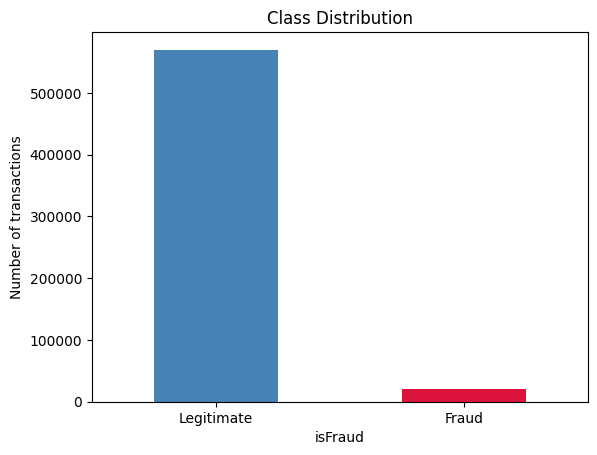

In [24]:
import matplotlib.pyplot as plt

df["isFraud"].value_counts().plot(
    kind="bar",
    color=["steelblue", "crimson"]
)

plt.xticks([0,1], ["Legitimate", "Fraud"], rotation=0)
plt.ylabel("Number of transactions")
plt.title("Class Distribution")
plt.show()

In [25]:
g = (
    df.groupby("ProductCD")["isFraud"]
      .agg(["size", "mean"])
)

g = g[g["size"] >= 1000]   # keep only reliable groups
g["fraud_%"] = (g["mean"] * 100).round(2)

g.sort_values("fraud_%", ascending=False)

,size,mean,fraud_%
ProductCD,,,
C,68519,0.116873,11.69
S,11628,0.058996,5.90
H,33024,0.047662,4.77
R,37699,0.037826,3.78
W,439670,0.020399,2.04


Time

Create time features

In [26]:
SECONDS_IN_DAY = 24 * 60 * 60

df = df.assign(
    day=df["TransactionDT"] // SECONDS_IN_DAY,
    hour=(df["TransactionDT"] // 3600) % 24,
    weekday=(df["TransactionDT"] // SECONDS_IN_DAY) % 7,
    month=(df["TransactionDT"] // SECONDS_IN_DAY) // 30,
)

test_df = test_df.assign(
    day=test_df["TransactionDT"] // SECONDS_IN_DAY,
    hour=(test_df["TransactionDT"] // 3600) % 24,
    weekday=(test_df["TransactionDT"] // SECONDS_IN_DAY) % 7,
    month=(test_df["TransactionDT"] // SECONDS_IN_DAY) // 30,
)

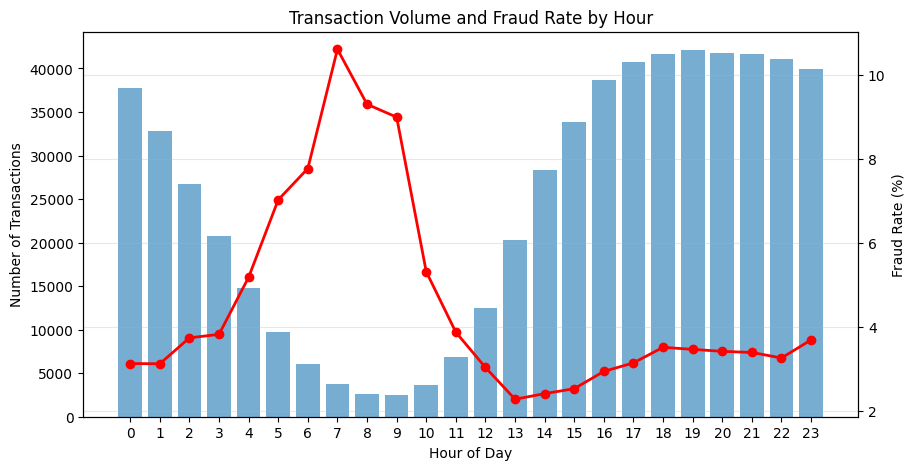

In [27]:
hourly = df.groupby("hour")["isFraud"].agg(
    Transactions="size",
    Fraud_Rate="mean"
)

fig, ax1 = plt.subplots(figsize=(10,5))

# Transaction volume
ax1.bar(hourly.index, hourly["Transactions"], alpha=0.6, label="Transactions")
ax1.set_xlabel("Hour of Day")
ax1.set_ylabel("Number of Transactions")

# Fraud rate
ax2 = ax1.twinx()
ax2.plot(hourly.index,
         hourly["Fraud_Rate"]*100,
         color="red",
         marker="o",
         linewidth=2,
         label="Fraud Rate")
ax2.set_ylabel("Fraud Rate (%)")

plt.title("Transaction Volume and Fraud Rate by Hour")
plt.xticks(range(24))
plt.grid(axis="y", alpha=0.3)

plt.show()

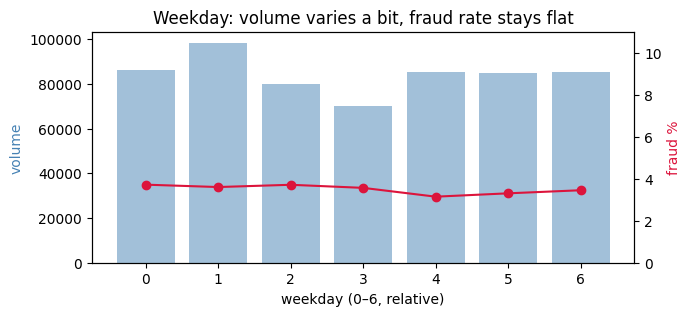

In [28]:
df['weekday'] = df['day'].astype(int) % 7

by_wd = df.groupby('weekday')['isFraud'].agg(['size', 'mean'])

fig, ax1 = plt.subplots(figsize=(7,3))
ax1.bar(by_wd.index, by_wd['size'], color='steelblue', alpha=0.5)
ax1.set_xlabel('weekday (0–6, relative)'); ax1.set_ylabel('volume', color='steelblue')

ax2 = ax1.twinx()
ax2.plot(by_wd.index, by_wd['mean']*100, color='crimson', marker='o')
ax2.set_ylabel('fraud %', color='crimson')
ax2.set_ylim(0, 11)          # SAME scale as the hour chart — this is the key line

plt.title('Weekday: volume varies a bit, fraud rate stays flat'); plt.show()

df = df.drop(columns='weekday')     # tested → no signal → dropped

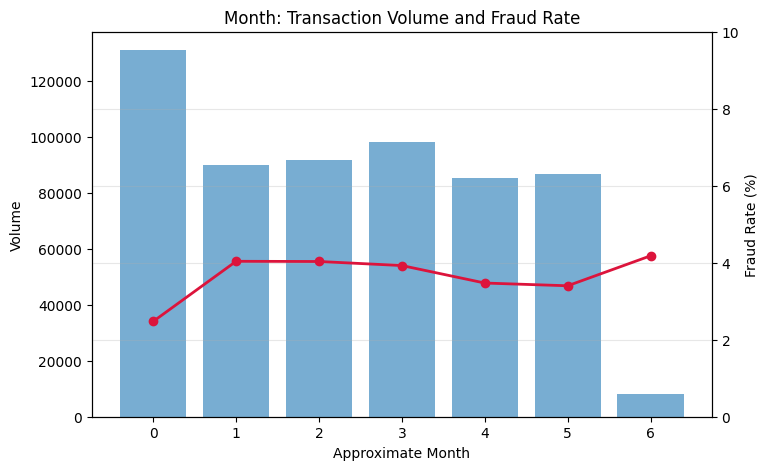

In [29]:
monthly = df.groupby("month")["isFraud"].agg(
    Transactions="size",
    Fraud_Rate="mean"
)

fig, ax1 = plt.subplots(figsize=(8,5))

# Transaction volume
ax1.bar(monthly.index, monthly["Transactions"], alpha=0.6)
ax1.set_xlabel("Approximate Month")
ax1.set_ylabel("Volume")

# Fraud rate
ax2 = ax1.twinx()
ax2.plot(
    monthly.index,
    monthly["Fraud_Rate"] * 100,
    color="crimson",
    marker="o",
    linewidth=2
)
ax2.set_ylabel("Fraud Rate (%)")
ax2.set_ylim(0, 10)   # Fixed scale for fair comparison

plt.title("Month: Transaction Volume and Fraud Rate")
plt.grid(axis="y", alpha=0.3)

plt.show()

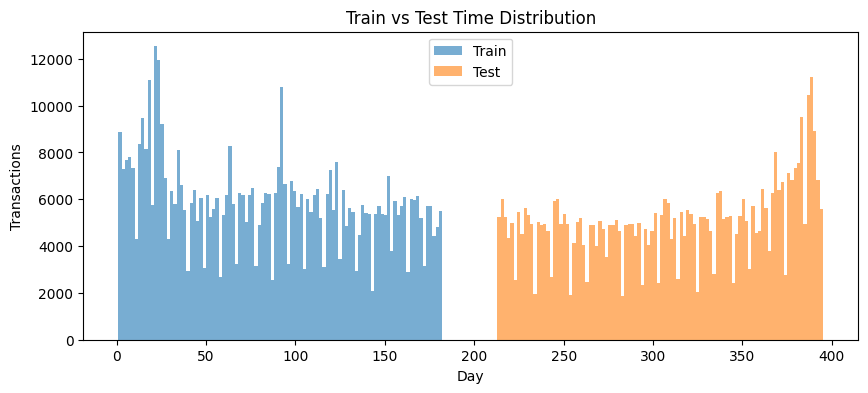

In [30]:
plt.figure(figsize=(10,4))

plt.hist(df["day"], bins=100, alpha=0.6, label="Train")
plt.hist(test_df["day"], bins=100, alpha=0.6, label="Test")

plt.legend()
plt.xlabel("Day")
plt.ylabel("Transactions")
plt.title("Train vs Test Time Distribution")
plt.show()

In [31]:
print("Train:", df["day"].min(), "to", df["day"].max())
print("Test :", test_df["day"].min(), "to", test_df["day"].max())

Train: 1 to 182
Test : 213 to 395


Time-based validation split

In [32]:
# Sort chronologically first — this is the step that makes the split honest
df_sorted = df.sort_values('day').reset_index(drop=True)

# Hold out the last ~15% of rows by time as validation
split_idx = int(len(df_sorted) * 0.85)
train_part = df_sorted.iloc[:split_idx]
val_part   = df_sorted.iloc[split_idx:]

print(f"Train part: days {train_part['day'].min():.0f}-{train_part['day'].max():.0f}, "
      f"{len(train_part):,} rows, fraud rate {train_part['isFraud'].mean()*100:.2f}%")
print(f"Val part:   days {val_part['day'].min():.0f}-{val_part['day'].max():.0f}, "
      f"{len(val_part):,} rows, fraud rate {val_part['isFraud'].mean()*100:.2f}%")

X_train, y_train = train_part.drop(columns=['isFraud']), train_part['isFraud']
X_val,   y_val   = val_part.drop(columns=['isFraud']),   val_part['isFraud']

Train part: days 1-152, 501,959 rows, fraud rate 3.50%
Val part:   days 152-182, 88,581 rows, fraud rate 3.48%


Missingness

In [33]:
# For each column family, check if missing rate lines up cleanly with another column
# A near-100% missing rate inside one product group = structural

families = {
    'C': [f'C{i}' for i in range(1, 15)],
    'D': [f'D{i}' for i in range(1, 16)],
    'M': [f'M{i}' for i in range(1, 10)],
    'id': [c for c in df.columns if c.startswith('id_')]
}

for family_name, cols in families.items():
    print(f"\n--- {family_name} family missing % by ProductCD ---")
    for col in cols[:3]:  # check first 3 as representatives
        if col in df.columns:
            result = df.groupby('ProductCD')[col].apply(
                lambda x: round(x.isna().mean() * 100, 1)
            )
            print(f"{col}: {result.to_dict()}")


--- C family missing % by ProductCD ---
C1: {'C': 0.0, 'H': 0.0, 'R': 0.0, 'S': 0.0, 'W': 0.0}
C2: {'C': 0.0, 'H': 0.0, 'R': 0.0, 'S': 0.0, 'W': 0.0}
C3: {'C': 0.0, 'H': 0.0, 'R': 0.0, 'S': 0.0, 'W': 0.0}

--- D family missing % by ProductCD ---
D1: {'C': 0.3, 'H': 0.1, 'R': 0.1, 'S': 0.0, 'W': 0.2}
D2: {'C': 70.5, 'H': 95.4, 'R': 88.6, 'S': 41.3, 'W': 37.0}
D3: {'C': 60.9, 'H': 99.2, 'R': 96.7, 'S': 74.0, 'W': 32.6}

--- M family missing % by ProductCD ---
M1: {'C': 100.0, 'H': 100.0, 'R': 100.0, 'S': 100.0, 'W': 27.3}
M2: {'C': 100.0, 'H': 100.0, 'R': 100.0, 'S': 100.0, 'W': 27.3}
M3: {'C': 100.0, 'H': 100.0, 'R': 100.0, 'S': 100.0, 'W': 27.3}

--- id family missing % by ProductCD ---
id_01: {'C': 9.2, 'H': 0.4, 'R': 0.4, 'S': 0.4, 'W': 100.0}
id_02: {'C': 11.0, 'H': 2.8, 'R': 3.2, 'S': 3.0, 'W': 100.0}
id_03: {'C': 60.4, 'H': 54.2, 'R': 57.4, 'S': 31.1, 'W': 100.0}


In [34]:
# Show what fraud rate looks like before and after hypothetical mean imputation
# for a column we know has informative missingness

col = 'D1'  # pick any D column with decent missing rate

present = df[col].notna()
fraud_present = df.loc[present, 'isFraud'].mean() * 100
fraud_missing = df.loc[~present, 'isFraud'].mean() * 100
fraud_overall = df['isFraud'].mean() * 100

print(f"Fraud rate when {col} IS present:  {fraud_present:.2f}%")
print(f"Fraud rate when {col} IS missing:  {fraud_missing:.2f}%")
print(f"Overall fraud rate (the 'mean'):   {fraud_overall:.2f}%")
print()
print("If we impute missing with mean, we're telling the model")
print(f"these {(~present).sum():,} rows are 'average' — but they're actually")
print(f"running at {fraud_missing:.2f}% fraud vs the average {fraud_overall:.2f}%.")
print("That gap IS the signal. Imputing erases it.")

Fraud rate when D1 IS present:  3.50%
Fraud rate when D1 IS missing:  3.62%
Overall fraud rate (the 'mean'):   3.50%

If we impute missing with mean, we're telling the model
these 1,269 rows are 'average' — but they're actually
running at 3.62% fraud vs the average 3.50%.
That gap IS the signal. Imputing erases it.


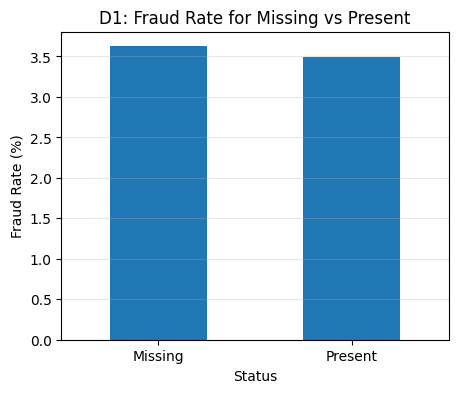

In [35]:
col = "D1"

fraud_rates = (
    df.assign(Status=df[col].isna().map({True: "Missing", False: "Present"}))
      .groupby("Status")["isFraud"]
      .mean() * 100
)

fraud_rates.plot(kind="bar", figsize=(5,4))

plt.ylabel("Fraud Rate (%)")
plt.title(f"{col}: Fraud Rate for Missing vs Present")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.show()

In [36]:
import numpy as np

# Suspicious values that might represent "missing"
# rather than real measurements
suspicious = [-999, -9999, 999, 9999, -1, 0, -999999]

numeric_cols = df.select_dtypes(include=['float32', 'float64',
                                          'int8', 'int16',
                                          'int32', 'int64']).columns

print("Scanning for suspicious placeholder values...\n")
for col in numeric_cols:
    col_min = df[col].min()
    col_max = df[col].max()

    for val in suspicious:
        count = (df[col] == val).sum()
        if count > 0:
            # Only flag if the value looks out of place
            # e.g. a sudden -999 in a column that otherwise has normal values
            col_mean = df[col].mean()
            col_std  = df[col].std()
            z_score  = abs((val - col_mean) / (col_std + 1e-9))

            if z_score > 5:  # more than 5 std away from mean = suspicious
                print(f"  {col}: value {val} appears {count:,} times "
                      f"| z-score {z_score:.1f} | "
                      f"range [{col_min:.1f}, {col_max:.1f}]")

Scanning for suspicious placeholder values...

  C1: value 999 appears 1 times | z-score 7.4 | range [0.0, 4685.0]
  C4: value 999 appears 2 times | z-score 14.5 | range [0.0, 2253.0]
  C6: value 999 appears 3 times | z-score 13.9 | range [0.0, 2253.0]
  C7: value 999 appears 1 times | z-score 16.2 | range [0.0, 2255.0]
  C10: value 999 appears 1 times | z-score 10.4 | range [0.0, 3257.0]
  C11: value 999 appears 1 times | z-score 10.5 | range [0.0, 3188.0]
  C12: value 999 appears 1 times | z-score 11.5 | range [0.0, 3188.0]
  V1: value 0 appears 17 times | z-score 135.3 | range [0.0, 1.0]
  V8: value 0 appears 24 times | z-score 5.5 | range [0.0, 8.0]
  V14: value 0 appears 257 times | z-score 44.7 | range [0.0, 1.0]
  V25: value 0 appears 14,465 times | z-score 5.3 | range [0.0, 7.0]
  V41: value 0 appears 308 times | z-score 37.0 | range [0.0, 1.0]
  V46: value 0 appears 348 times | z-score 6.1 | range [0.0, 6.0]
  V65: value 0 appears 173 times | z-score 54.5 | range [0.0, 1.0]
  

In [37]:
# Test whether simply NOT having a value correlates with fraud
# independent of what the value itself says when present

cols_to_test = (
    [f'D{i}' for i in range(1, 16)] +
    ['dist1', 'dist2']
)

rows = []
for col in cols_to_test:
    if col not in df.columns:
        continue

    present = df[col].notna()
    n_missing = (~present).sum()
    n_present = present.sum()

    if n_missing < 100 or n_present < 100:
        continue  # not enough rows in one group to trust the rate

    fraud_when_missing = df.loc[~present, 'isFraud'].mean() * 100
    fraud_when_present = df.loc[present,  'isFraud'].mean() * 100
    overall            = df['isFraud'].mean() * 100
    gap                = abs(fraud_when_missing - fraud_when_present)

    rows.append({
        'column':             col,
        'missing_%':          round((~present).mean() * 100, 1),
        'fraud_when_missing': round(fraud_when_missing, 2),
        'fraud_when_present': round(fraud_when_present, 2),
        'gap':                round(gap, 2)
    })

import pandas as pd
result = pd.DataFrame(rows).sort_values('gap', ascending=False)
print(result.to_string(index=False))
print(f"\nOverall fraud rate: {df['isFraud'].mean()*100:.2f}%")
print("\nColumns with a large gap are strong candidates for a presence flag.")

column  missing_%  fraud_when_missing  fraud_when_present   gap
    D7       93.4                2.70               14.88 12.18
   D12       89.0                2.48               11.74  9.26
   D14       89.5                2.55               11.60  9.05
   D13       89.5                2.62               11.04  8.42
    D6       87.6                2.50               10.55  8.04
    D8       87.3                2.49               10.45  7.96
    D9       87.3                2.49               10.45  7.96
 dist2       93.6                3.06                9.92  6.85
   D11       47.3                5.21                1.96  3.25
 dist1       59.7                4.52                2.00  2.52
    D2       47.5                4.56                2.54  2.02
   D10       12.9                5.11                3.26  1.85
   D15       15.1                4.80                3.27  1.53
    D3       44.5                4.20                2.94  1.27
    D5       52.5                3.16   

In [38]:
# Use the gap table from step 6 to decide which columns earn a flag
# Threshold: gap > 2% AND minimum sample size in both groups > 1000

MIN_GAP      = 2.0   # percentage points
MIN_SAMPLES  = 1000  # minimum rows in both the present and missing group

flags_built = []

for _, row in result.iterrows():
    col      = row['column']
    gap      = row['gap']
    n_miss   = (~df[col].notna()).sum()
    n_pres   = df[col].notna().sum()

    if gap >= MIN_GAP and n_miss >= MIN_SAMPLES and n_pres >= MIN_SAMPLES:
        flag_name = f'{col}_missing_flag'

        df[flag_name]      = df[col].isna().astype(int)
        test_df[flag_name] = test_df[col].isna().astype(int)

        flags_built.append({
            'flag':               flag_name,
            'gap_%_points':       gap,
            'fraud_if_missing_%': row['fraud_when_missing'],
            'fraud_if_present_%': row['fraud_when_present']
        })

print(f"Presence flags built: {len(flags_built)}")
print(pd.DataFrame(flags_built).to_string(index=False))

Presence flags built: 11
              flag  gap_%_points  fraud_if_missing_%  fraud_if_present_%
   D7_missing_flag         12.18                2.70               14.88
  D12_missing_flag          9.26                2.48               11.74
  D14_missing_flag          9.05                2.55               11.60
  D13_missing_flag          8.42                2.62               11.04
   D6_missing_flag          8.04                2.50               10.55
   D8_missing_flag          7.96                2.49               10.45
   D9_missing_flag          7.96                2.49               10.45
dist2_missing_flag          6.85                3.06                9.92
  D11_missing_flag          3.25                5.21                1.96
dist1_missing_flag          2.52                4.52                2.00
   D2_missing_flag          2.02                4.56                2.54


Email columns

In [39]:
def fraud_by(col, min_n=500):
    """Fraud rate per value of a column (values with at least min_n rows)."""
    g = df.groupby(df[col].fillna('MISSING'), observed=True)['isFraud'].agg(['size','mean'])
    g = g[g['size'] >= min_n].sort_values('mean', ascending=False)
    g['fraud_%'] = (g['mean']*100).round(1)
    return g[['size','fraud_%']]

In [40]:
print(fraud_by('P_emaildomain').head(10))
print(fraud_by('R_emaildomain').head(10))

                 size  fraud_%
P_emaildomain                 
mail.com          559     19.0
outlook.com      5096      9.5
live.com.mx       749      5.5
hotmail.com     45250      5.3
gmail.com      228355      4.4
icloud.com       6267      3.1
comcast.net      7888      3.1
charter.net       816      3.1
MISSING         94456      3.0
bellsouth.net    1909      2.8
                 size  fraud_%
R_emaildomain                 
outlook.com      2507     16.5
icloud.com       1398     12.9
gmail.com       57147     11.9
hotmail.com     27509      7.8
live.com.mx       754      5.8
yahoo.com       11842      5.2
live.com          762      5.0
aol.com          3701      3.5
anonymous.com   20529      2.9
MISSING        453249      2.1


In [41]:
print('distinct P domains:', df['P_emaildomain'].nunique())   # 59
print('distinct R domains:', df['R_emaildomain'].nunique())   # 60
print('P missing:', f"{df['P_emaildomain'].isna().mean()*100:.0f}%")   # 16%
print('R missing:', f"{df['R_emaildomain'].isna().mean()*100:.0f}%")   # 77%

distinct P domains: 59
distinct R domains: 60
P missing: 16%
R missing: 77%


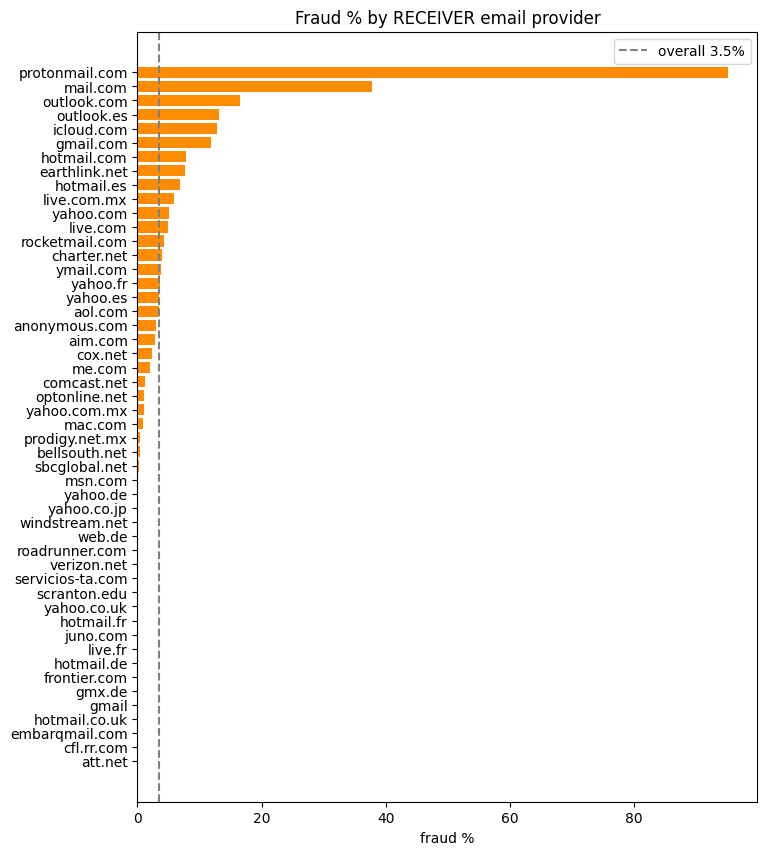

In [42]:
g = df.groupby('R_emaildomain')['isFraud'].agg(['size', 'mean'])   # per provider: count + fraud share
g = g[g['size'] >= 30]                                             # lower fence (30), or we lose protonmail (41 rows)
g = g.sort_values('mean')

plt.figure(figsize=(8, 10))
plt.barh(g.index, g['mean']*100, color='darkorange')
plt.axvline(df['isFraud'].mean()*100, color='gray', ls='--', label='overall 3.5%')
plt.xlabel('fraud %'); plt.title('Fraud % by RECEIVER email provider'); plt.legend()
plt.show()

In [43]:
df.groupby('ProductCD')['P_emaildomain'].apply(lambda s: round(s.isna().mean()*100, 1))

ProductCD
C      3.1
H      0.0
R      0.1
S    100.0
W     18.3
Name: P_emaildomain, dtype: float64

In [44]:
df.groupby('ProductCD')['R_emaildomain'].apply(lambda s: round(s.isna().mean()*100, 1))

ProductCD
C      3.1
H     32.8
R      0.0
S      5.1
W    100.0
Name: R_emaildomain, dtype: float64

In [45]:
both = df['P_emaildomain'].notna() & df['R_emaildomain'].notna()
same = both & (df['P_emaildomain'] == df['R_emaildomain'])

print(f'both emails present: {both.mean()*100:.1f}% of rows')
print(f'fraud when SAME domain:      {df.loc[same,"isFraud"].mean()*100:.1f}%')
print(f'fraud when DIFFERENT domain: {df.loc[both & ~same,"isFraud"].mean()*100:.1f}%')

both emails present: 21.4% of rows
fraud when SAME domain:      9.7%
fraud when DIFFERENT domain: 2.9%


New features:
is_protonmail Protonmail (anonymous email service) is extreme here: 41% fraud as buyer email, 95% as receiver email (small groups, but 39 fraud of 41 rows is not luck). The flag combines both columns with an OR - hard for a tree to build alone.

P_eq_R When buyer email = receiver email, fraud is much higher (8.8% vs 3.2% inside product H) - likely a thief sending gift purchases to himself. Trees cannot compare two columns in one question, so we hand them the comparison as a column.

In [46]:
for d in [df, test_df]:
    d['is_protonmail'] = (d['P_emaildomain'].eq('protonmail.com') |
                          d['R_emaildomain'].eq('protonmail.com')).astype(int)
    d['P_eq_R'] = ((d['P_emaildomain'].notna()) &
                   (d['P_emaildomain'] == d['R_emaildomain'])).astype(int)

In [47]:
all_domains = pd.concat([
    df['P_emaildomain'], df['R_emaildomain'],
    test_df['P_emaildomain'], test_df['R_emaildomain']
]).dropna().unique()

print(len(all_domains))
print(sorted(all_domains))

60
['aim.com', 'anonymous.com', 'aol.com', 'att.net', 'bellsouth.net', 'cableone.net', 'centurylink.net', 'cfl.rr.com', 'charter.net', 'comcast.net', 'cox.net', 'earthlink.net', 'embarqmail.com', 'frontier.com', 'frontiernet.net', 'gmail', 'gmail.com', 'gmx.de', 'hotmail.co.uk', 'hotmail.com', 'hotmail.de', 'hotmail.es', 'hotmail.fr', 'icloud.com', 'juno.com', 'live.com', 'live.com.mx', 'live.fr', 'mac.com', 'mail.com', 'me.com', 'msn.com', 'netzero.com', 'netzero.net', 'optonline.net', 'outlook.com', 'outlook.es', 'prodigy.net.mx', 'protonmail.com', 'ptd.net', 'q.com', 'roadrunner.com', 'rocketmail.com', 'sbcglobal.net', 'sc.rr.com', 'scranton.edu', 'servicios-ta.com', 'suddenlink.net', 'twc.com', 'verizon.net', 'web.de', 'windstream.net', 'yahoo.co.jp', 'yahoo.co.uk', 'yahoo.com', 'yahoo.com.mx', 'yahoo.de', 'yahoo.es', 'yahoo.fr', 'ymail.com']


In [48]:
# 1. Normalise odd domains FIRST
domain_fixes = {
    'cfl.rr.com': 'roadrunner.com',
    'sc.rr.com':  'roadrunner.com',
    'gmail':      'gmail.com',
}

for d in [df, test_df]:
    for col in ['P_emaildomain', 'R_emaildomain']:
        d[col] = d[col].replace(domain_fixes)

# 2. THEN split into provider + suffix
def split_email(series):
    provider = series.str.split('.').str[0]
    suffix   = series.str.split('.', n=1).str[1]
    return provider, suffix

for d in [df, test_df]:
    d['P_provider'], d['P_suffix'] = split_email(d['P_emaildomain'])
    d['R_provider'], d['R_suffix'] = split_email(d['R_emaildomain'])

# 3. Confirm the columns now exist before mapping
print(df[['P_emaildomain', 'P_provider', 'P_suffix']].dropna().head(10))
print('\nUnique providers:', sorted(df['P_provider'].dropna().unique()))

    P_emaildomain P_provider P_suffix
1       gmail.com      gmail      com
2     outlook.com    outlook      com
3       yahoo.com      yahoo      com
4       gmail.com      gmail      com
5       gmail.com      gmail      com
6       yahoo.com      yahoo      com
7        mail.com       mail      com
8   anonymous.com  anonymous      com
9       yahoo.com      yahoo      com
10      gmail.com      gmail      com

Unique providers: ['aim', 'anonymous', 'aol', 'att', 'bellsouth', 'cableone', 'centurylink', 'charter', 'comcast', 'cox', 'earthlink', 'embarqmail', 'frontier', 'frontiernet', 'gmail', 'gmx', 'hotmail', 'icloud', 'juno', 'live', 'mac', 'mail', 'me', 'msn', 'netzero', 'optonline', 'outlook', 'prodigy', 'protonmail', 'ptd', 'q', 'roadrunner', 'rocketmail', 'sbcglobal', 'servicios-ta', 'suddenlink', 'twc', 'verizon', 'web', 'windstream', 'yahoo', 'ymail']


In [49]:
provider_groups = {
    # Microsoft
    'hotmail': 'microsoft', 'outlook': 'microsoft',
    'live': 'microsoft', 'msn': 'microsoft',

    # Yahoo
    'yahoo': 'yahoo', 'ymail': 'yahoo', 'rocketmail': 'yahoo',

    # Apple
    'icloud': 'apple', 'me': 'apple', 'mac': 'apple',

    # AOL
    'aol': 'aol', 'aim': 'aol',

    # AT&T (absorbed SBC, BellSouth, Prodigy)
    'att': 'att', 'sbcglobal': 'att',
    'bellsouth': 'att', 'prodigy': 'att',

    # Charter / Spectrum (absorbed Time Warner Cable + Road Runner)
    'charter': 'spectrum', 'roadrunner': 'spectrum', 'twc': 'spectrum',

    # CenturyLink (absorbed Embarq, Qwest)
    'centurylink': 'centurylink', 'embarqmail': 'centurylink', 'q': 'centurylink',

    # Frontier
    'frontier': 'frontier', 'frontiernet': 'frontier',

    # United Online
    'juno': 'unitedonline', 'netzero': 'unitedonline',

    # Altice USA
    'optonline': 'altice', 'suddenlink': 'altice',

    # United Internet (German)
    'gmx': 'unitedinternet', 'web': 'unitedinternet',

    # Google
    'gmail': 'google',
}

for d in [df, test_df]:
    d['P_provider_group'] = d['P_provider'].replace(provider_groups)
    d['R_provider_group'] = d['R_provider'].replace(provider_groups)

In [50]:
print(df['P_provider_group'].value_counts())

g = df.groupby('P_provider_group')['isFraud'].agg(['size', 'mean'])
g['fraud_%'] = (g['mean'] * 100).round(1)
print(g[g['size'] >= 500].sort_values('fraud_%', ascending=False))

P_provider_group
google            228851
yahoo             105969
microsoft          59477
anonymous          36998
aol                28604
att                 9119
apple               8225
comcast             7888
verizon             2705
spectrum            1687
cox                 1393
altice              1186
unitedonline         748
centurylink          654
mail                 559
earthlink            514
frontier             475
unitedinternet       389
windstream           305
cableone             159
protonmail            76
ptd                   68
servicios-ta          35
Name: count, dtype: int64
                    size      mean  fraud_%
P_provider_group                           
mail                 559  0.189624     19.0
microsoft          59477  0.053298      5.3
google            228851  0.043496      4.3
comcast             7888  0.031187      3.1
apple               8225  0.028936      2.9
aol                28604  0.022969      2.3
anonymous          36998  0.02

In [51]:
for col in ['P_emaildomain', 'P_provider', 'P_provider_group', 'P_suffix']:
    print(f"{col:20s} {df[col].nunique()} unique values")

P_emaildomain        56 unique values
P_provider           42 unique values
P_provider_group     23 unique values
P_suffix             9 unique values


In [52]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder

email_cols = ['P_emaildomain', 'R_emaildomain',
              'P_provider_group', 'R_provider_group',
              'P_suffix', 'R_suffix']

# Confirm all six source columns exist before encoding
missing = [c for c in email_cols if c not in df.columns]
print("Missing source columns:", missing)

Missing source columns: []


In [53]:
import pandas as pd

email_cols = ['P_emaildomain', 'R_emaildomain',
              'P_provider_group', 'R_provider_group',
              'P_suffix', 'R_suffix']

for col in email_cols:
    combined = pd.concat([df[col], test_df[col]])
    freq = combined.value_counts(normalize=True)
    df[col + '_freq'] = df[col].map(freq)
    test_df[col + '_freq'] = test_df[col].map(freq)

print("Frequency columns created:", [c for c in df.columns if c.endswith('_freq')])

Frequency columns created: ['P_emaildomain_freq', 'R_emaildomain_freq', 'P_provider_group_freq', 'R_provider_group_freq', 'P_suffix_freq', 'R_suffix_freq']


In [54]:
from sklearn.preprocessing import OrdinalEncoder

enc = OrdinalEncoder()
combined = pd.concat([df[email_cols], test_df[email_cols]]).astype(str)
enc.fit(combined)

le_names = [c + '_le' for c in email_cols]
df[le_names] = enc.transform(df[email_cols].astype(str))
test_df[le_names] = enc.transform(test_df[email_cols].astype(str))

print("Ordinal columns created:", le_names)

Ordinal columns created: ['P_emaildomain_le', 'R_emaildomain_le', 'P_provider_group_le', 'R_provider_group_le', 'P_suffix_le', 'R_suffix_le']


In [55]:
created = [c for c in df.columns if c.endswith('_freq') or c.endswith('_le')]
print(f"{len(created)} columns created")
print(df[created].isna().sum())
print(df[created].head())

12 columns created
P_emaildomain_freq        94456
R_emaildomain_freq       453249
P_provider_group_freq     94456
R_provider_group_freq    453249
P_suffix_freq             94456
R_suffix_freq            453249
P_emaildomain_le              0
R_emaildomain_le              0
P_provider_group_le           0
R_provider_group_le           0
P_suffix_le                   0
R_suffix_le                   0
dtype: int64
   P_emaildomain_freq  R_emaildomain_freq  P_provider_group_freq  \
0                 NaN                 NaN                    NaN   
1            0.467871                 NaN               0.467871   
2            0.010641                 NaN               0.121025   
3            0.195788                 NaN               0.205389   
4            0.467871                 NaN               0.467871   

   R_provider_group_freq  P_suffix_freq  R_suffix_freq  P_emaildomain_le  \
0                    NaN            NaN            NaN              30.0   
1                    Na

In [56]:
print(df.groupby('P_emaildomain_le')['isFraud'].agg(['size','mean'])
        .sort_values('mean', ascending=False).head(5))

                  size      mean
P_emaildomain_le                
37.0                76  0.407895
27.0               559  0.189624
35.0               438  0.130137
0.0                315  0.126984
34.0              5096  0.094584


In [57]:
email_features = [c for c in df.columns
                  if ('emaildomain' in c or 'provider' in c or 'suffix' in c)
                  and (c.endswith('_freq') or c.endswith('_le'))]
print(email_features)
print(f"\n{len(email_features)} encoded columns")
print(df[email_features].isna().sum())

['P_emaildomain_freq', 'R_emaildomain_freq', 'P_provider_group_freq', 'R_provider_group_freq', 'P_suffix_freq', 'R_suffix_freq', 'P_emaildomain_le', 'R_emaildomain_le', 'P_provider_group_le', 'R_provider_group_le', 'P_suffix_le', 'R_suffix_le']

12 encoded columns
P_emaildomain_freq        94456
R_emaildomain_freq       453249
P_provider_group_freq     94456
R_provider_group_freq    453249
P_suffix_freq             94456
R_suffix_freq            453249
P_emaildomain_le              0
R_emaildomain_le              0
P_provider_group_le           0
R_provider_group_le           0
P_suffix_le                   0
R_suffix_le                   0
dtype: int64


In [58]:
df.P_emaildomain_freq

0              NaN
1         0.467871
2         0.010641
3         0.195788
4         0.467871
            ...   
590535         NaN
590536    0.467871
590537    0.467871
590538    0.056060
590539    0.467871
Name: P_emaildomain_freq, Length: 590540, dtype: float64

In [59]:
df.P_emaildomain_le

0         30.0
1         14.0
2         34.0
3         52.0
4         14.0
          ... 
590535    30.0
590536    14.0
590537    14.0
590538     2.0
590539    14.0
Name: P_emaildomain_le, Length: 590540, dtype: float64

In [60]:
cols = [
    "P_emaildomain",
    "P_provider",
    "P_provider_group",
    "P_suffix",
    "P_emaildomain_freq",
    "P_provider_group_freq",
    "P_emaildomain_le"
]

df[cols].head(30)

,P_emaildomain,P_provider,P_provider_group,P_suffix,P_emaildomain_freq,P_provider_group_freq,P_emaildomain_le
0,NaN,NaN,NaN,NaN,NaN,NaN,30.0
1,gmail.com,gmail,google,com,0.467871,0.467871,14.0
2,outlook.com,outlook,microsoft,com,0.010641,0.121025,34.0
3,yahoo.com,yahoo,yahoo,com,0.195788,0.205389,52.0
4,gmail.com,gmail,google,com,0.467871,0.467871,14.0
5,gmail.com,gmail,google,com,0.467871,0.467871,14.0
6,yahoo.com,yahoo,yahoo,com,0.195788,0.205389,52.0
7,mail.com,mail,mail,com,0.001238,0.001238,27.0
8,anonymous.com,anonymous,anonymous,com,0.076117,0.076117,1.0
9,yahoo.com,yahoo,yahoo,com,0.195788,0.205389,52.0


TransactionAmt

In [61]:
df['TransactionAmt'].describe()

count    590540.000000
mean        135.027161
std         239.162689
min           0.251000
25%          43.320999
50%          68.769001
75%         125.000000
max       31937.390625
Name: TransactionAmt, dtype: float64

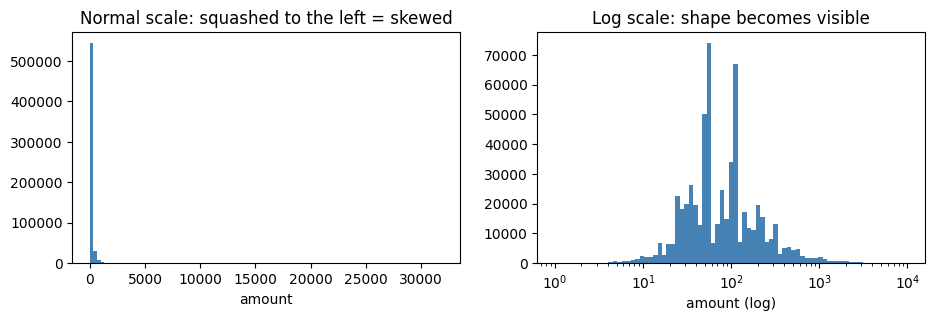

In [62]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3))

# left: normal scale - the skew is obvious
ax[0].hist(df['TransactionAmt'], bins=100, color='steelblue')
ax[0].set_title('Normal scale: squashed to the left = skewed')
ax[0].set_xlabel('amount')

# right: log scale - now we can actually see the shape
bins = np.logspace(0, 4, 80)
ax[1].hist(df['TransactionAmt'], bins=bins, color='steelblue')
ax[1].set_xscale('log')
ax[1].set_title('Log scale: shape becomes visible')
ax[1].set_xlabel('amount (log)')
plt.show()

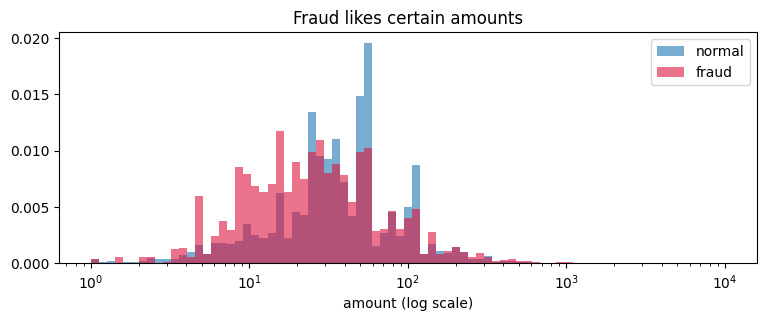

In [63]:
bins = np.logspace(0, 4, 80)     # bins from 1 to 10,000, evenly spread in log
plt.figure(figsize=(9,3))
plt.hist(df.loc[df.isFraud==0, 'TransactionAmt'], bins=bins, alpha=0.6, label='normal', density=True)
plt.hist(df.loc[df.isFraud==1, 'TransactionAmt'], bins=bins, alpha=0.6, label='fraud', color='crimson', density=True)
plt.xscale('log')
plt.xlabel('amount (log scale)'); plt.legend(); plt.title('Fraud likes certain amounts'); plt.show()

Amount alone is a weak clue

In [64]:
foreign = (df['TransactionAmt'] * 100 % 1) != 0     # True if more than 2 decimals

print('rows like this:', round(foreign.mean()*100, 1), '%')
print('fraud in these rows:', round(df.loc[foreign, 'isFraud'].mean()*100, 1), '%')
print('fraud in normal rows:', round(df.loc[~foreign, 'isFraud'].mean()*100, 1), '%')

rows like this: 14.0 %
fraud in these rows: 9.2 %
fraud in normal rows: 2.6 %


New Feature:
is_foreign_amt: flags any foreign transaction

In [65]:
for d in [df, test_df]:
    left = (d['TransactionAmt'].astype('float64') * 100) % 1
    d['is_foreign_amt'] = ((left > 0.01) & (left < 0.99)).astype(int)

In [66]:
summary = (
    df.groupby("is_foreign_amt")["isFraud"]
      .agg(
          Transactions="size",
          Fraud_Rate="mean"
      )
)

summary["Fraud_Rate"] *= 100
summary["Fraud_Rate"] = summary["Fraud_Rate"].round(2)

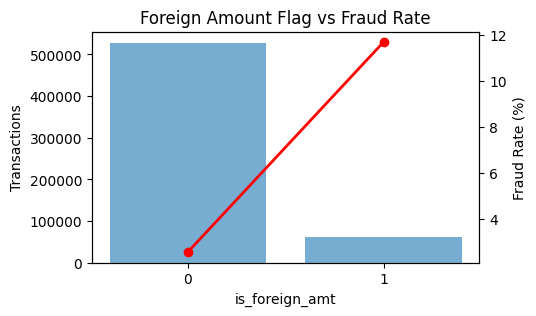

In [67]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(5,3))

ax1.bar(summary.index.astype(str), summary["Transactions"], alpha=0.6)
ax1.set_xlabel("is_foreign_amt")
ax1.set_ylabel("Transactions")

ax2 = ax1.twinx()
ax2.plot(summary.index.astype(str), summary["Fraud_Rate"],
         color="red", marker="o", linewidth=2)
ax2.set_ylabel("Fraud Rate (%)")

plt.title("Foreign Amount Flag vs Fraud Rate")
plt.show()

D-series Features

In [68]:
d_cols = [f"D{i}" for i in range(1, 16)]

summary = pd.DataFrame({
    "Missing %": df[d_cols].isna().mean() * 100,
    "Min": df[d_cols].min(),
    "Median": df[d_cols].median(),
    "Max": df[d_cols].max(),
    "Has Decimals": [
        ((df[c].dropna() % 1) != 0).any()
        for c in d_cols
    ]
})

summary.round(2)

,Missing %,Min,Median,Max,Has Decimals
D1,0.21,0.0,3.000000,640.000000,False
D2,47.55,0.0,97.000000,640.000000,False
D3,44.51,0.0,8.000000,819.000000,False
D4,28.60,-122.0,26.000000,869.000000,False
D5,52.47,0.0,10.000000,819.000000,False
D6,87.61,-83.0,0.000000,873.000000,False
D7,93.41,0.0,0.000000,843.000000,False
D8,87.31,0.0,37.880001,1707.790039,True
D9,87.31,0.0,0.670000,0.960000,True
D10,12.87,0.0,15.000000,876.000000,False


In [69]:
for col in d_cols:
    print(col, df[col].min(), df[col].max())

D1 0.0 640.0
D2 0.0 640.0
D3 0.0 819.0
D4 -122.0 869.0
D5 0.0 819.0
D6 -83.0 873.0
D7 0.0 843.0
D8 0.0 1707.7916259765625
D9 0.0 0.9583330154418945
D10 0.0 876.0
D11 -53.0 670.0
D12 -83.0 648.0
D13 0.0 847.0
D14 -193.0 878.0
D15 -83.0 879.0


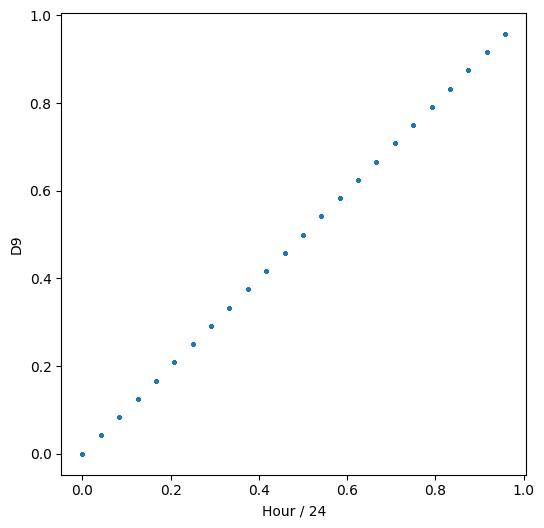

In [70]:
df["hour_frac"] = df["hour"] / 24

plt.figure(figsize=(6,6))

plt.scatter(
    df["hour_frac"],
    df["D9"],
    s=2,
    alpha=0.2
)

plt.xlabel("Hour / 24")
plt.ylabel("D9")

plt.show()

In [71]:
print(df["hour_frac"].corr(df["D9"]))

0.9999999999996125


In [72]:
df["D8_int"] = np.floor(df["D8"])
df["D8_frac"] = df["D8"] % 1

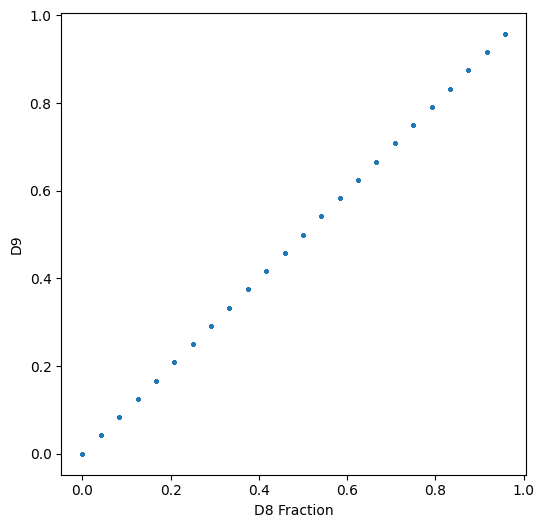

In [73]:
plt.figure(figsize=(6,6))

plt.scatter(
    df["D8_frac"],
    df["D9"],
    s=2,
    alpha=0.2
)

plt.xlabel("D8 Fraction")
plt.ylabel("D9")

plt.show()

In [74]:
print(df["D8_frac"].corr(df["D9"]))

0.9999999997984834


In [75]:
remaining = [c for c in d_cols if c not in ["D8", "D9"]]

daily = (
    df.groupby("day")[remaining]
      .mean()
)

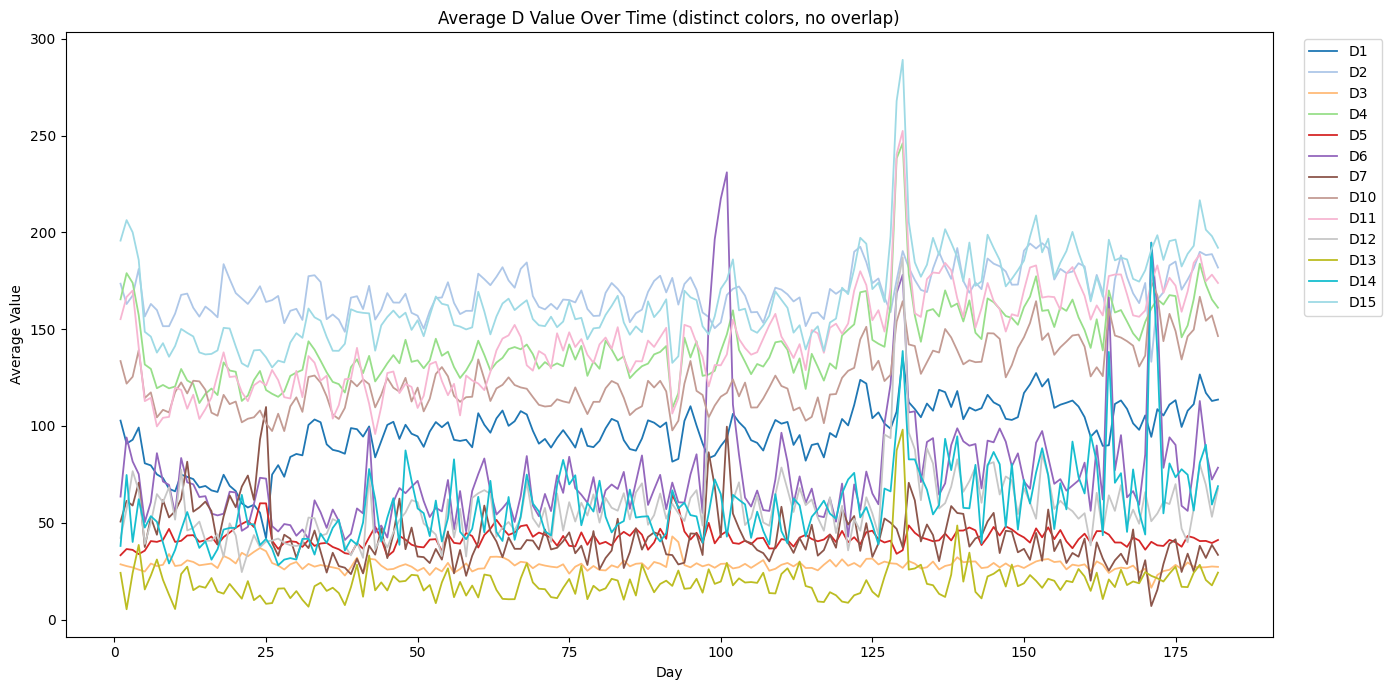

In [76]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

D_cols = ['D1','D2','D3','D4','D5','D6','D7','D10','D11','D12','D13','D14','D15']

# Group by day and average, same as before
monthly_avg = df.groupby('day')[D_cols].mean()

# tab20 has 20 distinct colors, enough to cover all 13-15 lines without repeating
colors = cm.tab20(np.linspace(0, 1, len(D_cols)))

plt.figure(figsize=(14, 7))
for i, col in enumerate(D_cols):
    plt.plot(monthly_avg.index, monthly_avg[col], label=col, color=colors[i], linewidth=1.3)

plt.xlabel('Day')
plt.ylabel('Average Value')
plt.title('Average D Value Over Time (distinct colors, no overlap)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', ncol=1)
plt.tight_layout()
plt.show()

C-series Features

In [77]:
C_cols = [f'C{i}' for i in range(1, 15)]

pd.DataFrame({
    'median': df[C_cols].median(),
    'p95':    df[C_cols].quantile(0.95),
    'max':    df[C_cols].max()
}).round(1)

,median,p95,max
C1,1.0,22.0,4685.0
C2,1.0,27.0,5691.0
C3,0.0,0.0,26.0
C4,0.0,1.0,2253.0
C5,0.0,9.0,349.0
C6,1.0,15.0,2253.0
C7,0.0,1.0,2255.0
C8,0.0,2.0,3331.0
C9,1.0,9.0,210.0
C10,0.0,2.0,3257.0


In [78]:
for c in C_cols:
    test_df[c] = test_df[c].clip(upper=df[c].max())

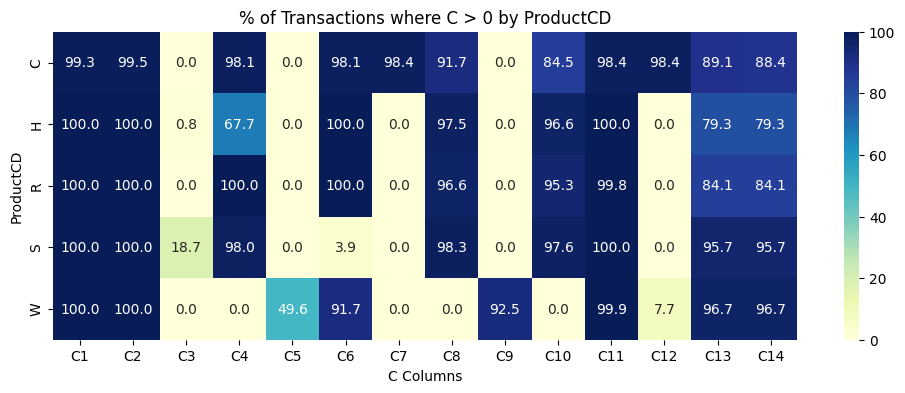

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt

C_cols = [f'C{i}' for i in range(1, 15)]

# % of transactions where C > 0, by ProductCD
c_product = (
    df.groupby('ProductCD')[C_cols]
      .apply(lambda x: (x > 0).mean() * 100)
      .round(1)
)

plt.figure(figsize=(12,4))

sns.heatmap(
    c_product,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    vmin=0,
    vmax=100
)

plt.title("% of Transactions where C > 0 by ProductCD")
plt.xlabel("C Columns")
plt.ylabel("ProductCD")
plt.show()

C1 and C2 are populated for almost every transaction, regardless of ProductCD. So these are general-purpose features, not tied to a particular product.

C7, C9 and C12 only carries information for a particular product.

Only Product W uses C5. So C5 may be measuring something that only exists for Product W.

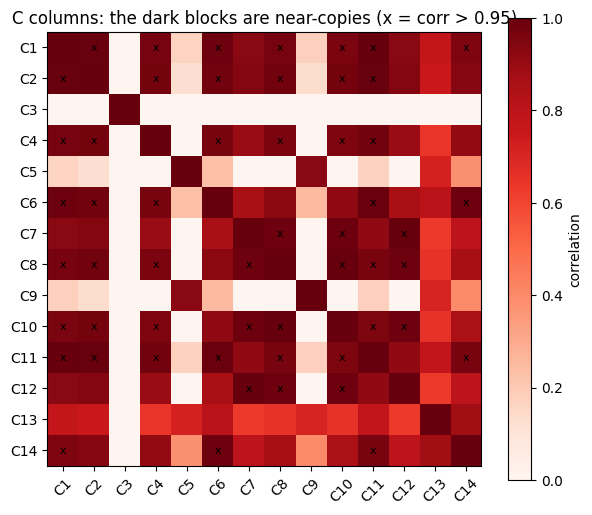

In [80]:
corr = df[C_cols].corr()

plt.figure(figsize=(7, 6))
plt.imshow(corr, cmap='Reds', vmin=0, vmax=1)
plt.colorbar(label='correlation')
plt.xticks(range(14), C_cols, rotation=45); plt.yticks(range(14), C_cols)
for i in range(14):
    for j in range(14):
        if corr.values[i, j] > 0.95 and i != j:
            plt.text(j, i, 'x', ha='center', va='center', fontsize=8)
plt.title('C columns: the dark blocks are near-copies (x = corr > 0.95)'); plt.show()

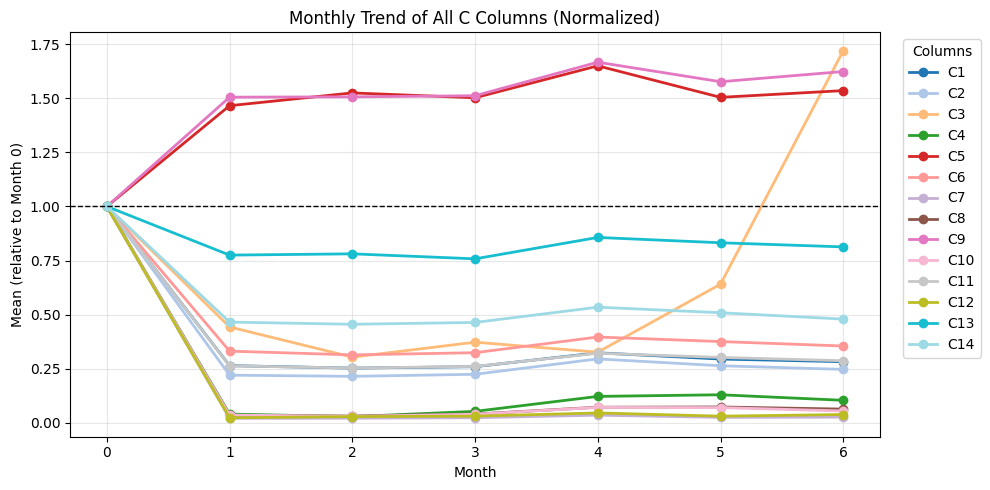

In [81]:
import matplotlib.pyplot as plt
import numpy as np

C_cols = [f"C{i}" for i in range(1, 15)]

# Month buckets
month = (df["day"] // 30).astype(int)

# Monthly mean
monthly = df.groupby(month)[C_cols].mean()

# Normalize to Month 0
monthly_norm = monthly.divide(monthly.iloc[0])

# 14 distinct colors
colors = plt.cm.tab20(np.linspace(0, 1, len(C_cols)))

plt.figure(figsize=(10, 5))

for color, col in zip(colors, C_cols):
    plt.plot(
        monthly_norm.index,
        monthly_norm[col],
        marker="o",
        linewidth=2,
        color=color,
        label=col
    )

plt.axhline(1, color="black", linestyle="--", linewidth=1)

plt.xlabel("Month")
plt.ylabel("Mean (relative to Month 0)")
plt.title("Monthly Trend of All C Columns (Normalized)")
plt.xticks(monthly_norm.index)
plt.grid(alpha=0.3)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    title="Columns"
)

plt.tight_layout()
plt.show()

M-series Columns

In [82]:
M_cols = [f'M{i}' for i in range(1, 10)]

df[M_cols].head(15)

,M1,M2,M3,M4,M5,M6,M7,M8,M9
0,T,T,T,M2,F,T,NaN,NaN,NaN
1,NaN,NaN,NaN,M0,T,T,NaN,NaN,NaN
2,T,T,T,M0,F,F,F,F,F
3,NaN,NaN,NaN,M0,T,F,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,T,T,T,M1,F,T,NaN,NaN,NaN
6,T,T,T,M0,F,F,T,T,T
7,NaN,NaN,NaN,M0,F,F,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,T,T,T,M0,T,T,NaN,NaN,NaN


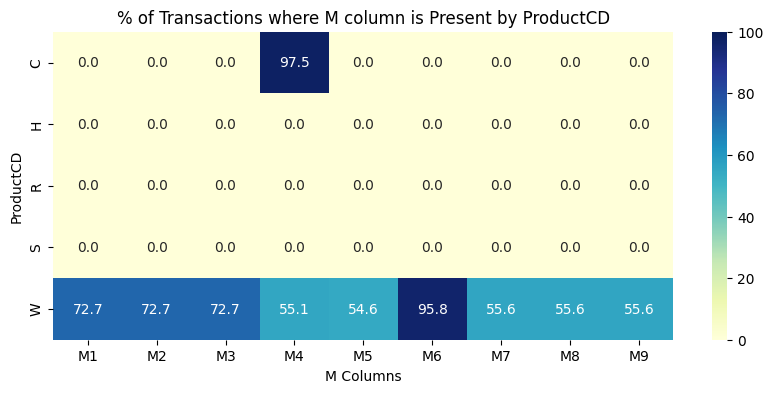

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt

M_cols = [f"M{i}" for i in range(1, 10)]

# Percentage of rows where each M column is present
m_product = (
    df.groupby("ProductCD")[M_cols]
      .apply(lambda x: x.notna().mean() * 100)
      .round(1)
)

plt.figure(figsize=(10,4))

sns.heatmap(
    m_product,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    vmin=0,
    vmax=100
)

plt.title("% of Transactions where M column is Present by ProductCD")
plt.ylabel("ProductCD")
plt.xlabel("M Columns")
plt.show()

      size  fraud_%
M4                 
M0  196405     3.66
M1   52826     2.71
M2   59865    11.37


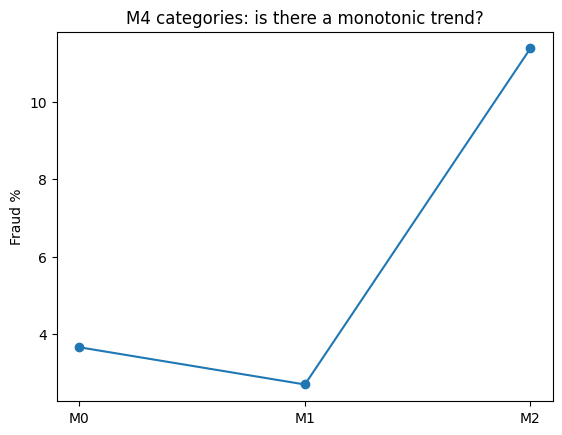

In [84]:
g = df.groupby('M4')['isFraud'].agg(['size', 'mean'])
g['fraud_%'] = (g['mean'] * 100).round(2)
print(g[['size', 'fraud_%']].sort_index())

# Visual check: does fraud rate step up/down monotonically across M0 -> M1 -> M2?
import matplotlib.pyplot as plt
order = ['M0', 'M1', 'M2']
rates = [g.loc[cat, 'mean'] * 100 for cat in order]
plt.plot(order, rates, marker='o')
plt.ylabel('Fraud %')
plt.title('M4 categories: is there a monotonic trend?')
plt.show()

In [85]:
df.groupby(['M4', 'ProductCD'])['isFraud'].mean()

M4  ProductCD
M0  C            0.114954
    W            0.032292
M1  C            0.124138
    W            0.026245
M2  C            0.117790
    W            0.055081
Name: isFraud, dtype: float64

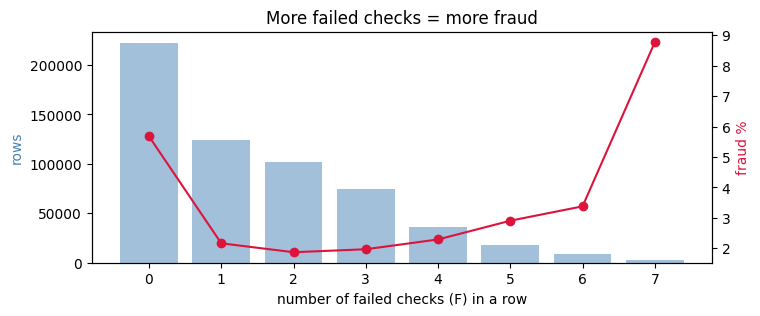

In [86]:
failcount = (df[M_cols] == 'F').sum(axis=1)
g = df.groupby(failcount)['isFraud'].agg(['size', 'mean'])

fig, ax1 = plt.subplots(figsize=(8, 3))
ax1.bar(g.index, g['size'], color='steelblue', alpha=0.5)      # how many rows have each failcount
ax1.set_xlabel('number of failed checks (F) in a row'); ax1.set_ylabel('rows', color='steelblue')
ax2 = ax1.twinx()
ax2.plot(g.index, g['mean']*100, color='crimson', marker='o')  # fraud % at each failcount
ax2.set_ylabel('fraud %', color='crimson')
plt.title('More failed checks = more fraud'); plt.show()

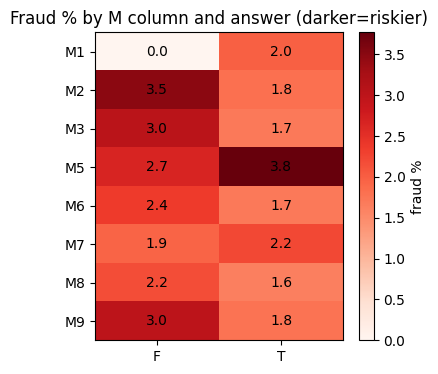

In [87]:
rows = []
for c in M_cols:
    for val in ['T', 'F']:
        m = df[c] == val
        if m.sum() > 0:
            rows.append({'M': c, 'answer': val, 'fraud_%': df.loc[m, 'isFraud'].mean()*100})
tab = pd.DataFrame(rows).pivot(index='M', columns='answer', values='fraud_%')

import matplotlib.pyplot as plt
plt.figure(figsize=(4, 4))
plt.imshow(tab, cmap='Reds', aspect='auto')
plt.colorbar(label='fraud %')
plt.xticks([0,1], tab.columns); plt.yticks(range(len(tab.index)), tab.index)
for i in range(len(tab.index)):
    for j in range(len(tab.columns)):
        plt.text(j, i, f'{tab.values[i,j]:.1f}', ha='center', va='center')
plt.title('Fraud % by M column and answer (darker=riskier)'); plt.show()

In [88]:
for d in [df, test_df]:
    d['M_failcount'] = (d[M_cols] == 'F').sum(axis=1)
    d['M_nancount']  = d[M_cols].isna().sum(axis=1)

In [89]:
# Define all three states within the M_failcount == 0 bucket
zero_fail = df['M_failcount'] == 0

genuinely_clean = zero_fail & (df['M_nancount'] == 0)
nothing_ran     = zero_fail & (df['M_nancount'] == len(M_cols))
partial         = zero_fail & (df['M_nancount'] > 0) & (df['M_nancount'] < len(M_cols))

for label, mask in [('All checks ran, all passed', genuinely_clean),
                    ('Partial - some ran, some did not', partial),
                    ('Nothing ran at all', nothing_ran)]:
    n = mask.sum()
    rate = df.loc[mask, 'isFraud'].mean() * 100
    print(f"{label:36s} | {n:>7,} rows | fraud {rate:.2f}%")

# Verify the three groups now fully account for the original bucket
total_split = genuinely_clean.sum() + partial.sum() + nothing_ran.sum()
print(f"\nOriginal M_failcount==0 bucket: {zero_fail.sum():,}")
print(f"Sum of all three groups:        {total_split:,}")
print(f"Unaccounted rows:               {zero_fail.sum() - total_split:,}")

All checks ran, all passed           |   3,199 rows | fraud 3.44%
Partial - some ran, some did not     | 131,387 rows | fraud 6.56%
Nothing ran at all                   |  88,031 rows | fraud 4.45%

Original M_failcount==0 bucket: 222,617
Sum of all three groups:        222,617
Unaccounted rows:               0


In [90]:
# Repeat the three-way comparison within ProductCD == W only
w = df[df['ProductCD'] == 'W']
zero_fail_w = w['M_failcount'] == 0

groups_w = {
    'All ran, all passed': zero_fail_w & (w['M_nancount'] == 0),
    'Partial':             zero_fail_w & (w['M_nancount'] > 0) & (w['M_nancount'] < len(M_cols)),
    'Nothing ran':         zero_fail_w & (w['M_nancount'] == len(M_cols)),
}

for label, mask in groups_w.items():
    n = mask.sum()
    if n > 0:
        print(f"{label:22s} | {n:>7,} rows | fraud {w.loc[mask, 'isFraud'].mean()*100:.2f}%")

print(f"\nBaseline fraud rate within W: {w['isFraud'].mean()*100:.2f}%")

All ran, all passed    |   3,199 rows | fraud 3.44%
Partial                |  64,602 rows | fraud 1.20%
Nothing ran            |   3,946 rows | fraud 1.62%

Baseline fraud rate within W: 2.04%


In [91]:
M_cols = [f'M{i}' for i in range(1, 10)]

for d in [df, test_df]:
    # A row where every M column is missing has no meaningful failcount
    no_checks_ran = d['M_nancount'] == len(M_cols)
    d.loc[no_checks_ran, 'M_failcount'] = np.nan

Set M_failcount to NaN where no M-checks ran at all, since a failcount of 0 there means "nothing was checked" rather than "nothing failed". These are two very different things collapsed into the same number. This leaves 0 meaning only "checks ran and all passed," so the column now measures one thing consistently

In [92]:
print("Rows set to NaN:", df['M_failcount'].isna().sum())

g = df.groupby('M_failcount', dropna=False)['isFraud'].agg(['size', 'mean'])
g['fraud_%'] = (g['mean'] * 100).round(2)
print(g[['size', 'fraud_%']])

Rows set to NaN: 88031
               size  fraud_%
M_failcount                 
0.0          134586     6.48
1.0          124351     2.16
2.0          101688     1.87
3.0           74477     1.97
4.0           36648     2.29
5.0           18243     2.91
6.0            9267     3.38
7.0            3249     8.77
NaN           88031     4.45


In [93]:
print("Train NaN count:", df['M_failcount'].isna().sum())
print("Test NaN count: ", test_df['M_failcount'].isna().sum())
print("Train failcount range:", df['M_failcount'].min(), "to", df['M_failcount'].max())
print("Test failcount range: ", test_df['M_failcount'].min(), "to", test_df['M_failcount'].max())

Train NaN count: 88031
Test NaN count:  77354
Train failcount range: 0.0 to 7.0
Test failcount range:  0.0 to 7.0


id_ columns

In [94]:
id_cols = [c for c in df.columns if c.startswith('id_')]
print(len(id_cols), 'columns')
df[id_cols].head(20)

38 columns


,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,NotFound,NaN,-480.0,New,NotFound,166.0,NaN,542.0,144.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,Android 7.0,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,NaN,100.0,NotFound,49.0,-300.0,New,NotFound,166.0,NaN,621.0,500.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,iOS 11.1.2,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [95]:
id_num = [c for c in id_cols if df[c].dtype != 'object']    # numeric ones
id_txt = [c for c in id_cols if df[c].dtype == 'object']    # text ones
print('numeric:', len(id_num), id_num[:8])
print('text:   ', len(id_txt), id_txt)

numeric: 23 ['id_01', 'id_02', 'id_03', 'id_04', 'id_05', 'id_06', 'id_07', 'id_08']
text:    15 ['id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38']


New Features

In [96]:
import numpy as np

pattern = r'^(.*?)(?:\s+(\d.*))?$'

for d in [df, test_df]:
    temp = d["id_30"].str.extract(pattern)

    d["id_30_OS"] = temp[0].str.strip()
    d["id_30_Version"] = temp[1]

In [97]:
df[["id_30_OS", "id_30_Version"]].head(10)

,id_30_OS,id_30_Version
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,Android,7.0
5,NaN,NaN
6,NaN,NaN
7,NaN,NaN
8,iOS,11.1.2
9,NaN,NaN


In [98]:
test_df[["id_30_OS", "id_30_Version"]].head(10)

,id_30_OS,id_30_Version
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN
5,NaN,NaN
6,NaN,NaN
7,NaN,NaN
8,NaN,NaN
9,NaN,NaN


In [99]:
rows = []
for c in ['id_12','id_15','id_16','id_28','id_29','id_35','id_36','id_37','id_38']:
    for val, grp in df.groupby(df[c].fillna('MISSING'))['isFraud']:
        if len(grp) >= 500:
            rows.append({'col': c, 'answer': str(val)[:10], 'n': len(grp),
                         'fraud_%': round(grp.mean()*100, 1)})
tab = pd.DataFrame(rows)
print(tab.to_string(index=False))

  col   answer      n  fraud_%
id_12    Found  21208      6.0
id_12  MISSING 446307      2.1
id_12 NotFound 123025      8.2
id_15    Found  67728     10.5
id_15  MISSING 449555      2.1
id_15      New  61612      4.9
id_15  Unknown  11645      9.2
id_16    Found  66324     10.7
id_16  MISSING 461200      2.3
id_16 NotFound  63016      4.8
id_28    Found  76232     10.3
id_28  MISSING 449562      2.1
id_28      New  64746      5.2
id_29    Found  74926     10.4
id_29  MISSING 449562      2.1
id_29 NotFound  66052      5.1
id_35        F  63171     12.3
id_35  MISSING 449555      2.1
id_35        T  77814      4.5
id_36        F 134066      8.2
id_36  MISSING 449555      2.1
id_36        T   6919      3.5
id_37        F  30533      6.6
id_37  MISSING 449555      2.1
id_37        T 110452      8.3
id_38        F  73922      9.8
id_38  MISSING 449555      2.1
id_38        T  67063      6.0


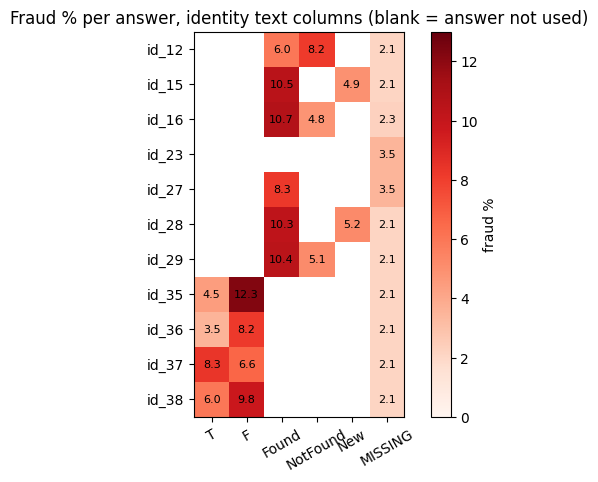

In [100]:
import numpy as np

cols   = ['id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_35', 'id_36', 'id_37', 'id_38']
answers = ['T', 'F', 'Found', 'NotFound', 'New', 'MISSING']   # the answers these columns use

grid = np.full((len(cols), len(answers)), np.nan)             # empty grid, NaN = answer not used

for i, c in enumerate(cols):
    vals = df[c].fillna('MISSING')
    for j, a in enumerate(answers):
        m = vals == a
        if m.sum() >= 500:                                    # sample-size rule
            grid[i, j] = df.loc[m, 'isFraud'].mean() * 100

plt.figure(figsize=(7, 5))
plt.imshow(grid, cmap='Reds', vmin=0, vmax=13)
plt.colorbar(label='fraud %')
plt.xticks(range(len(answers)), answers, rotation=30)
plt.yticks(range(len(cols)), cols)
for i in range(len(cols)):
    for j in range(len(answers)):
        if not np.isnan(grid[i, j]):
            plt.text(j, i, f'{grid[i,j]:.1f}', ha='center', va='center', fontsize=8)
plt.title('Fraud % per answer, identity text columns (blank = answer not used)')
plt.show()

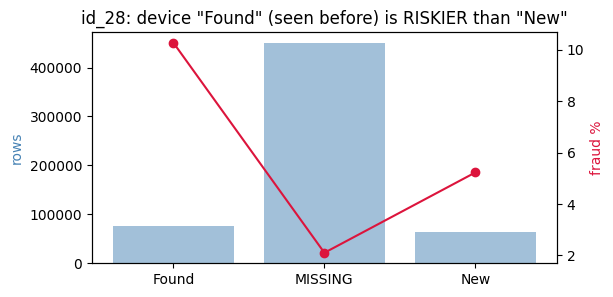

In [101]:
g = df.groupby(df['id_28'].fillna('MISSING'))['isFraud'].agg(['size','mean'])

fig, ax1 = plt.subplots(figsize=(6,3))
ax1.bar(g.index, g['size'], color='steelblue', alpha=0.5)
ax1.set_ylabel('rows', color='steelblue')
ax2 = ax1.twinx()
ax2.plot(range(len(g)), g['mean']*100, color='crimson', marker='o')
ax2.set_ylabel('fraud %', color='crimson')
plt.title('id_28: device "Found" (seen before) is RISKIER than "New"'); plt.show()

In [102]:
g = df.groupby(df['id_23'].fillna('MISSING'))['isFraud'].agg(['size','mean'])
g['fraud_%'] = (g['mean']*100).round(1)
print(g[['size','fraud_%']])

                        size  fraud_%
id_23                                
IP_PROXY:ANONYMOUS      1071     13.7
IP_PROXY:HIDDEN          609      5.6
IP_PROXY:TRANSPARENT    3489      7.0
MISSING               585371      3.5


In [103]:
print(df['id_30'].value_counts().head(8))
print(df['id_31'].value_counts().head(8))
print('\ndistinct browser strings:', df['id_31'].nunique())

# the trap: do test browsers even exist in train?
tr = set(df['id_31'].dropna()); te = set(test_df['id_31'].dropna())
print('test browser strings never seen in train:', len(te - tr), 'of', len(te))

id_30
Windows 10          21155
Windows 7           13110
iOS 11.2.1           3722
iOS 11.1.2           3699
Android 7.0          2871
Mac OS X 10_12_6     2559
Mac OS X 10_11_6     2348
iOS 11.3.0           2016
Name: count, dtype: int64
id_31
chrome 63.0              22000
mobile safari 11.0       13423
mobile safari generic    11474
ie 11.0 for desktop       9030
safari generic            8195
chrome 62.0               7182
chrome 65.0               6871
chrome 64.0               6711
Name: count, dtype: int64

distinct browser strings: 130
test browser strings never seen in train: 42 of 135


In [104]:
has_id = df['id_01'].notna()                  # True where an identity record exists

print('share with identity:', round(has_id.mean()*100, 1), '%')
print('fraud WITH identity:', round(df.loc[has_id, 'isFraud'].mean()*100, 2), '%')
print('fraud WITHOUT:      ', round(df.loc[~has_id, 'isFraud'].mean()*100, 2), '%')

share with identity: 24.4 %
fraud WITH identity: 7.85 %
fraud WITHOUT:       2.09 %


New feature: has_identity

In [105]:
for d in [df, test_df]:
    d['has_identity'] = d['id_01'].notna().astype(int)

In [106]:
with_id = df[df['has_identity'] == 1]          # only rows that have an identity record

g = with_id.groupby(with_id['DeviceInfo'].fillna('HIDDEN'))['isFraud'].agg(['size','mean'])
g['fraud_%'] = (g['mean']*100).round(1)
print(g[g['size'] >= 1000].sort_values('fraud_%', ascending=False).head(8)[['size','fraud_%']])

              size  fraud_%
DeviceInfo                 
HIDDEN       25567     10.6
Windows      47722      6.5
iOS Device   19782      6.3
rv:11.0       1901      4.0
MacOS        12573      2.2
Trident/7.0   7440      1.3


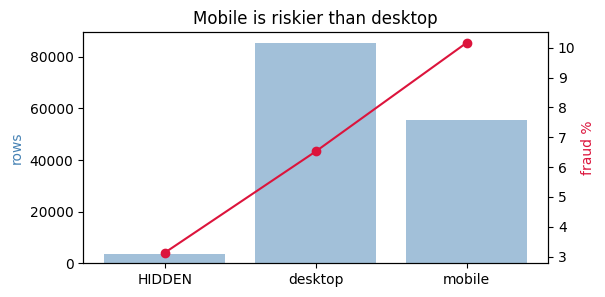

In [107]:
g = with_id.groupby(with_id['DeviceType'].fillna('HIDDEN'))['isFraud'].agg(['size','mean'])

fig, ax1 = plt.subplots(figsize=(6,3))
ax1.bar(g.index, g['size'], color='steelblue', alpha=0.5)      # how many rows per type
ax1.set_ylabel('rows', color='steelblue')
ax2 = ax1.twinx()
ax2.plot(range(len(g)), g['mean']*100, color='crimson', marker='o')   # fraud % per type
ax2.set_ylabel('fraud %', color='crimson')
plt.title('Mobile is riskier than desktop'); plt.show()

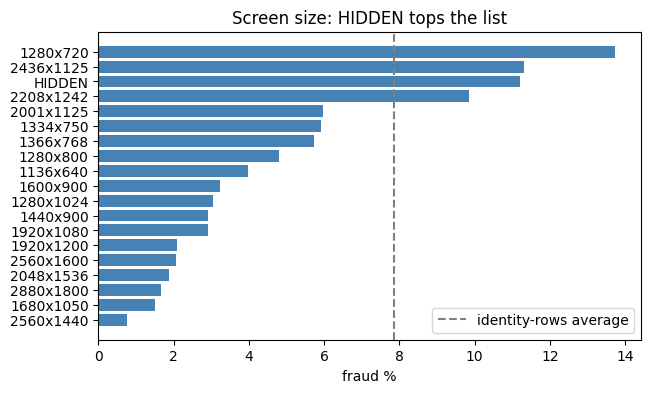

In [108]:
g = with_id.groupby(with_id['id_33'].fillna('HIDDEN'))['isFraud'].agg(['size','mean'])
g = g[g['size'] >= 1000].sort_values('mean')                   # keep big groups, sort for the chart

plt.figure(figsize=(7,4))
plt.barh(g.index.astype(str), g['mean']*100, color='steelblue')
plt.axvline(with_id['isFraud'].mean()*100, color='gray', ls='--', label='identity-rows average')
plt.xlabel('fraud %'); plt.legend()
plt.title('Screen size: HIDDEN tops the list'); plt.show()

1280x720 - a low, old-fashioned resolution: cheap older devices, and also the default screen size of many emulators (fake phones running on a PC - a classic fraud tool).

In [109]:
print(g.loc[['1280x720', '2436x1125', 'HIDDEN'], 'size'])

id_33
1280x720      1318
2436x1125     1484
HIDDEN       70944
Name: size, dtype: int64


In [110]:
id_cols = [c for c in df.columns if c.startswith('id_')]           # all identity columns
id_num  = [c for c in id_cols if df[c].dtype != 'object']          # the numeric ones
id_txt  = [c for c in id_cols if df[c].dtype == 'object']          # the text ones
print(len(id_num), 'numeric |', len(id_txt), 'text')

23 numeric | 17 text


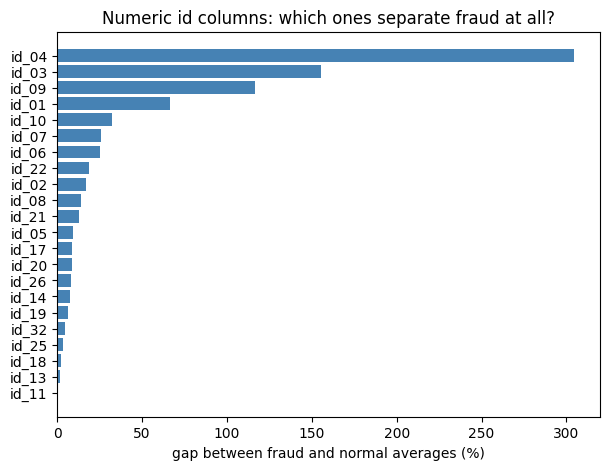

In [111]:
rows = []
for c in id_num:
    x = with_id[c]
    if x.notna().sum() > 5000:
        f = x[with_id['isFraud'] == 1].mean()
        n = x[with_id['isFraud'] == 0].mean()
        rows.append({'col': c, 'gap_%': abs(f-n) / (abs(n)+1e-9) * 100})
scout = pd.DataFrame(rows).sort_values('gap_%')

plt.figure(figsize=(7,5))
plt.barh(scout['col'], scout['gap_%'], color='steelblue')
plt.xlabel('gap between fraud and normal averages (%)')
plt.title('Numeric id columns: which ones separate fraud at all?'); plt.show()

V-series columns

In [112]:
families = {
    # "C": [c for c in df.columns if c.startswith("C") and c[1:].isdigit()],
    # "D": [c for c in df.columns if c.startswith("D") and c[1:].isdigit()],
    # "M": [c for c in df.columns if c.startswith("M") and c[1:].isdigit()],
    "V": [c for c in df.columns if c.startswith("V") and c[1:].isdigit()],
    # "Identity": [c for c in df.columns if c.startswith("id_")]
}

for name, cols in families.items():
    print(f"{name}: {len(cols)} columns")

V: 339 columns


In [113]:
V_cols = families['V']   # already defined earlier: 339 columns
print(f"Starting with {len(V_cols)} V columns")

# Group columns by exact NaN count -- columns missing in the
# same rows likely come from the same underlying calculation
nan_counts = df[V_cols].isna().sum()
v_groups = {}
for col, n in nan_counts.items():
    v_groups.setdefault(n, []).append(col)

v_groups = {n: cols for n, cols in v_groups.items() if len(cols) > 1}  # groups of 1 have nothing to compare

print(f"\n{len(v_groups)} distinct NaN-patterns among V columns:")
for n, cols in sorted(v_groups.items(), key=lambda x: -len(x[1])):
    pct = round(n / len(df) * 100, 1)
    print(f"  {n:>7,} missing ({pct}%) -> {len(cols):>3} columns : {cols[0]} ... {cols[-1]}")

Starting with 339 V columns

15 distinct NaN-patterns among V columns:
  460,110 missing (77.9%) ->  46 columns : V217 ... V278
      314 missing (0.1%) ->  43 columns : V95 ... V137
       12 missing (0.0%) ->  32 columns : V279 ... V321
  450,909 missing (76.4%) ->  31 columns : V167 ... V216
   76,073 missing (12.9%) ->  23 columns : V12 ... V34
   77,096 missing (13.1%) ->  22 columns : V53 ... V74
   89,164 missing (15.1%) ->  20 columns : V75 ... V94
  450,721 missing (76.3%) ->  19 columns : V169 ... V210
  168,969 missing (28.6%) ->  18 columns : V35 ... V52
  508,595 missing (86.1%) ->  18 columns : V138 ... V163
  508,189 missing (86.1%) ->  18 columns : V322 ... V339
  449,124 missing (76.1%) ->  16 columns : V220 ... V272
  279,287 missing (47.3%) ->  11 columns : V1 ... V11
  508,589 missing (86.1%) ->  11 columns : V143 ... V166
    1,269 missing (0.2%) ->  11 columns : V281 ... V315


Group with 460,110 missing rows -> 46 columns


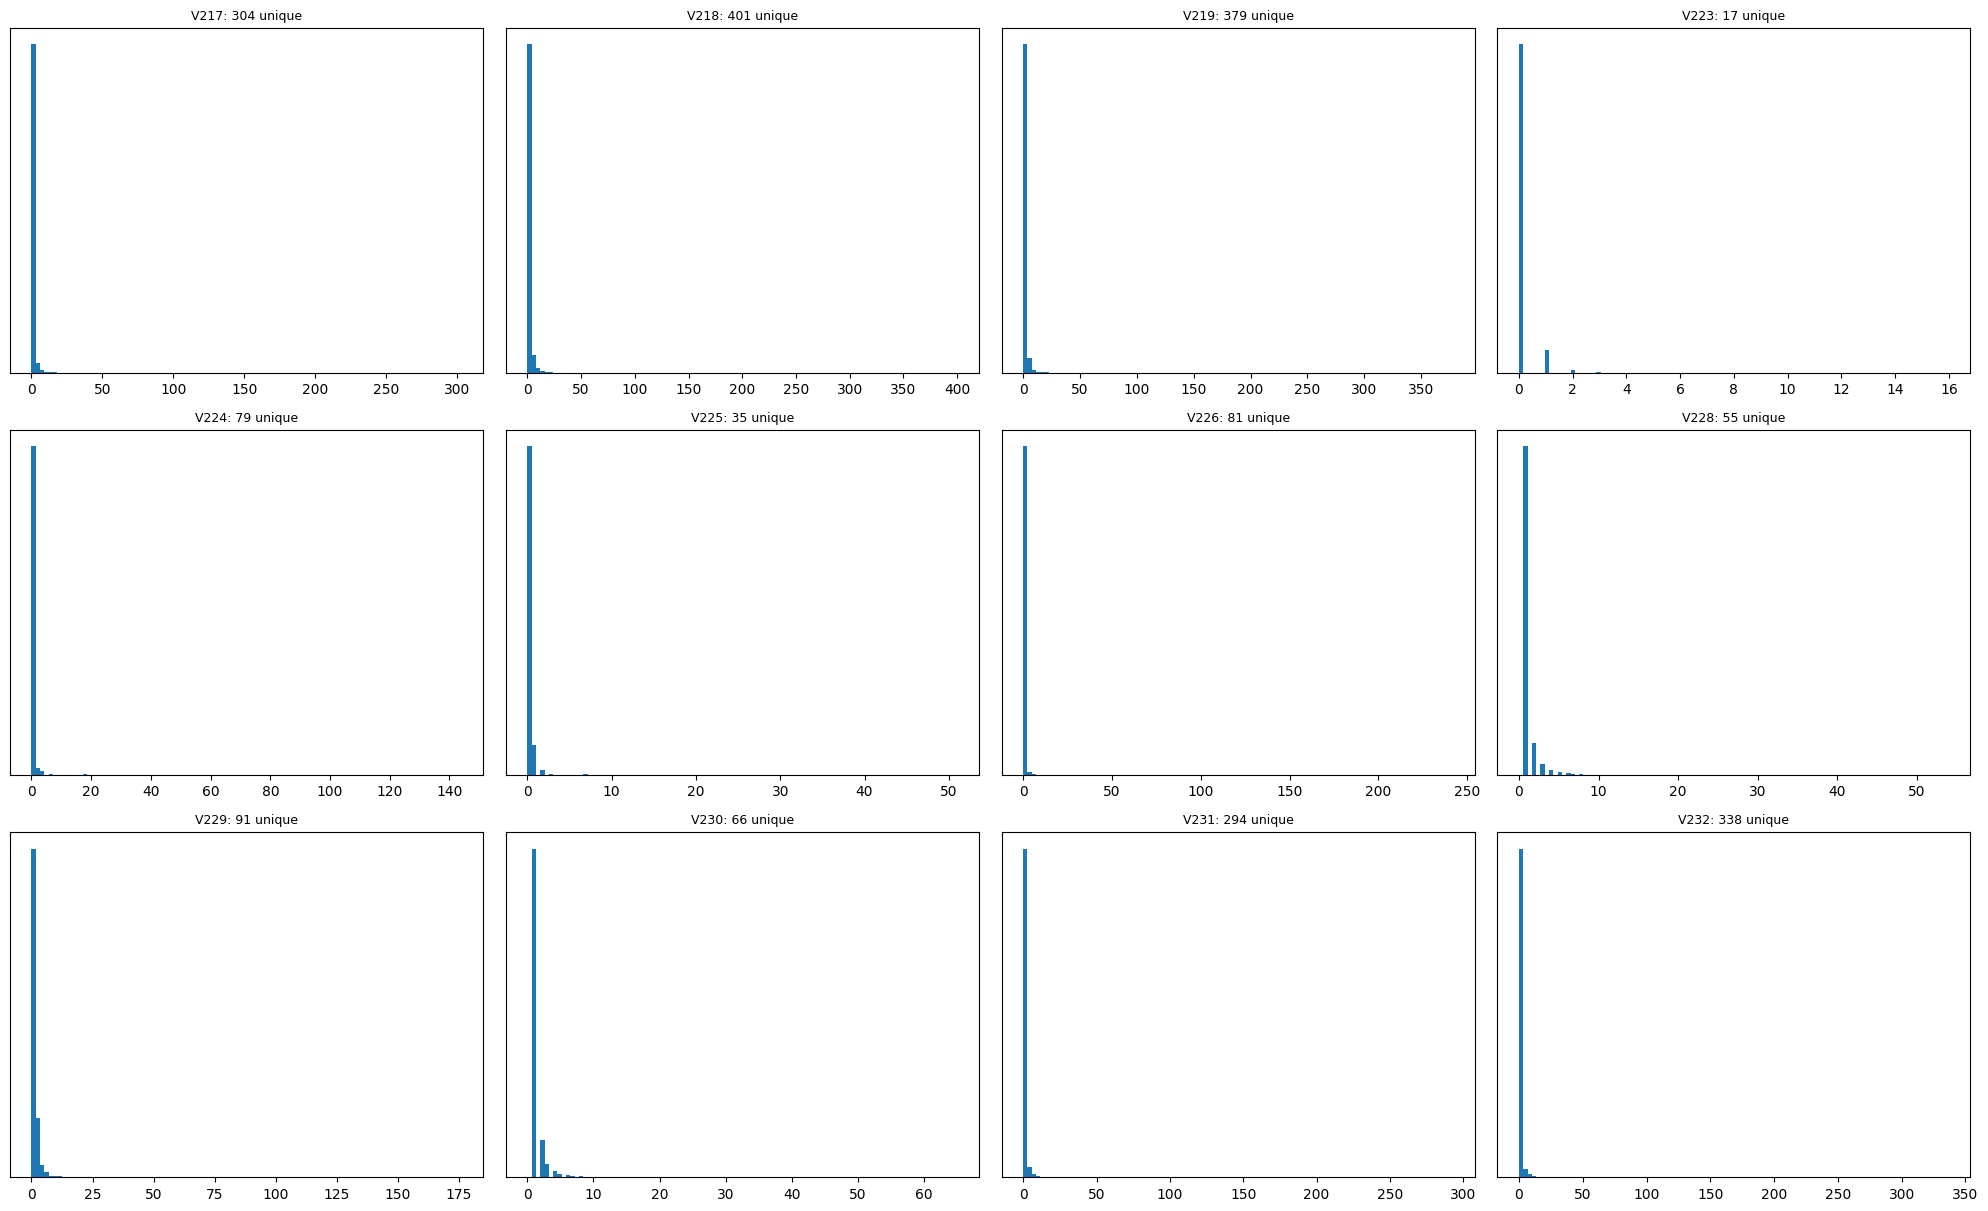

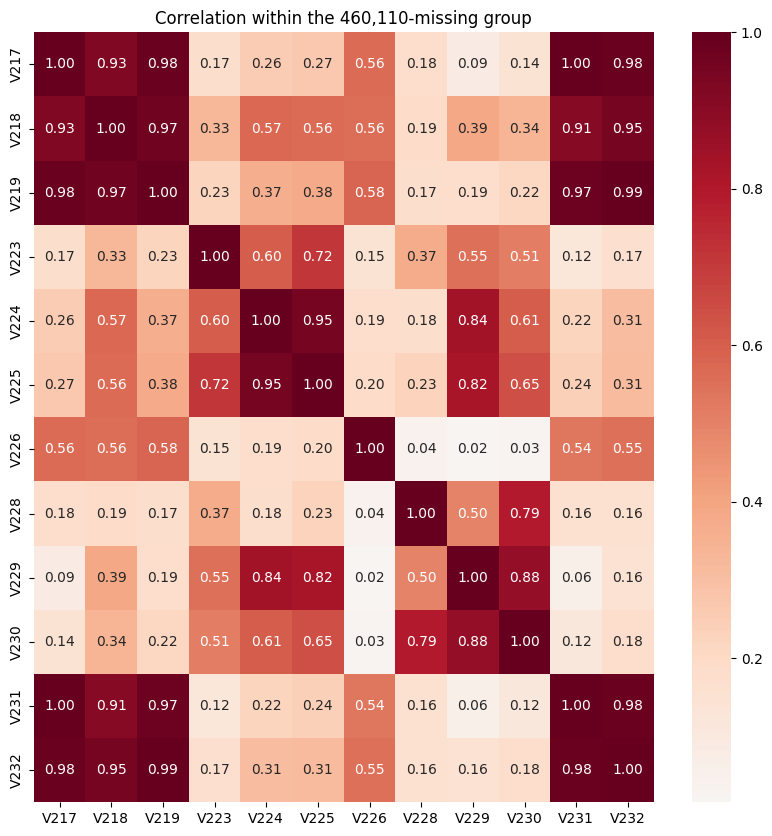

In [114]:
example_n = max(v_groups, key=lambda k: len(v_groups[k]))   # biggest group
example_cols = v_groups[example_n]
print(f"Group with {example_n:,} missing rows -> {len(example_cols)} columns")

n_show = min(len(example_cols), 12)
fig, axes = plt.subplots((n_show // 4) + 1, 4, figsize=(20, ((n_show // 4) + 1) * 4))
axes = axes.flatten()
idx = df[~df[example_cols[0]].isna()].index

for i, col in enumerate(example_cols[:n_show]):
    axes[i].hist(df.loc[idx, col], bins=100)
    axes[i].set_title(f"{col}: {df[col].nunique()} unique", fontsize=9)
    axes[i].set_yticks([])
for j in range(n_show, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout(); plt.show()

plt.figure(figsize=(10, 10))
sns.heatmap(df[example_cols[:n_show]].corr(), cmap='RdBu_r', annot=True, fmt='.2f', center=0)
plt.title(f'Correlation within the {example_n:,}-missing group')
plt.show()

In [115]:
def reduce_by_correlation(df, cols, threshold=0.75):
    """Drops any column that's >= threshold correlated with a column
    already kept. When two columns are near-duplicates, keeps whichever
    has more unique values (more granular = assumed more informative)."""
    if len(cols) == 1:
        return cols
    corr = df[cols].corr().abs()
    cols_sorted = sorted(cols, key=lambda c: -df[c].nunique())
    keep = []
    for col in cols_sorted:
        if all(corr.loc[col, k] < threshold for k in keep):
            keep.append(col)
    return keep

final_v_cols = []
for n, cols in v_groups.items():
    final_v_cols.extend(reduce_by_correlation(df, cols, threshold=0.75))

# add back columns that had a unique NaN-count all to themselves
# (nothing to compare them against, so nothing to drop)
singleton_cols = [c for c in V_cols if df[c].isna().sum() not in v_groups]
final_v_cols.extend(singleton_cols)

print(f"Original V columns: {len(V_cols)}")
print(f"Reduced V columns : {len(final_v_cols)}")

Original V columns: 339
Reduced V columns : 138


In [116]:
v_to_drop = [c for c in V_cols if c not in final_v_cols]

print(f"Dropping {len(v_to_drop)} V columns")

Dropping 201 V columns


In [117]:
df.drop(columns=v_to_drop, inplace=True)
test_df.drop(columns=v_to_drop, inplace=True)

In [118]:
len([c for c in df.columns if c.startswith("V")])

138

In [119]:
len(final_v_cols)

138

# UID
# Credits - Lord Kartik

In [120]:
# Create TransactionDT_date for both train and test

for dataset in [df, test_df]:
    dataset['TransactionDT_date'] = (
        dataset['TransactionDT'] / (24 * 60 * 60) + 0.7 - 1
    )

# Preview
print(df['TransactionDT_date'].head(20))
print(test_df['TransactionDT_date'].head(20))

0     0.700000
1     0.700012
2     0.700799
3     0.701146
4     0.701227
5     0.701273
6     0.701412
7     0.701493
8     0.701562
9     0.701574
10    0.701725
11    0.701794
12    0.701898
13    0.702141
14    0.702269
15    0.702523
16    0.702546
17    0.703102
18    0.703762
19    0.703819
Name: TransactionDT_date, dtype: float64
0     212.700278
1     212.700729
2     212.701273
3     212.701273
4     212.701354
5     212.701424
6     212.701736
7     212.702164
8     212.702373
9     212.702500
10    212.703171
11    212.703519
12    212.703565
13    212.703970
14    212.704086
15    212.704421
16    212.704606
17    212.705000
18    212.705000
19    212.705532
Name: TransactionDT_date, dtype: float64


In [121]:
# Create Starting_day for both train and test

for dataset in [df, test_df]:

    diff = dataset['TransactionDT_date'] - dataset['D1']

    dataset['Starting_day'] = np.where(
        diff >= 0,
        np.where(
            (diff - np.floor(diff)) > 0.7,
            np.floor(diff) + 1,
            np.floor(diff)
        ),
        np.where(
            (diff - np.ceil(diff)) > -0.3,
            np.ceil(diff),
            np.floor(diff)
        )
    ).astype(int)

/tmp/ipykernel_58/2874075363.py:19: RuntimeWarning: invalid value encountered in cast
  ).astype(int)
/tmp/ipykernel_58/2874075363.py:19: RuntimeWarning: invalid value encountered in cast
  ).astype(int)


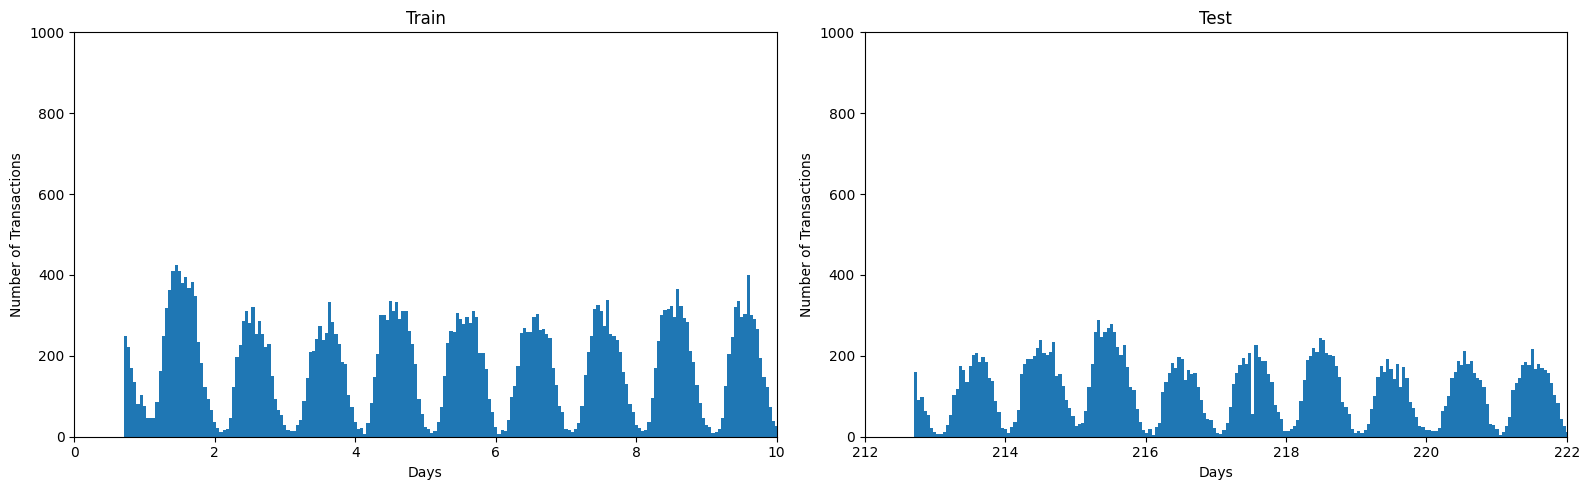

In [122]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# -------------------------
# Train
# -------------------------
axes[0].hist(df['TransactionDT_date'], bins=4000)
axes[0].set_xlim(0, 10)
axes[0].set_ylim(0, 1000)
axes[0].set_xlabel('Days')
axes[0].set_ylabel('Number of Transactions')
axes[0].set_title('Train')

# -------------------------
# Test
# -------------------------
axes[1].hist(test_df['TransactionDT_date'], bins=4000)
axes[1].set_xlim(212, 222)
axes[1].set_ylim(0, 1000)
axes[1].set_xlabel('Days')
axes[1].set_ylabel('Number of Transactions')
axes[1].set_title('Test')

plt.tight_layout()
plt.show()

In [123]:
uid_cols = [
    'Starting_day',
    'card1',
    'card2', 'card3', 'card4', 'card5', 'card6',
    'addr1',
    'P_emaildomain'
    # 'ProductCD'
]

datasets = {'train': df, 'test': test_df}
uid_group_dict = {}

for name, dataset in datasets.items():
    uid_group_dict[name] = (
        dataset.assign(P_emaildomain=dataset['P_emaildomain'].fillna('Missing'))
               .groupby(uid_cols)
    )

uid_groups = uid_group_dict['train']
test_uid_groups = uid_group_dict['test']

In [124]:
uid_summary = (
    df.groupby(uid_cols, dropna=False)
      .size()
      .reset_index(name='Transactions')
      .sort_values('Transactions', ascending=False)
)

test_uid_summary = (
    test_df.groupby(uid_cols, dropna=False)
           .size()
           .reset_index(name='Transactions')
           .sort_values('Transactions', ascending=False)
)

print("Train UID Summary")
display(uid_summary.head(20))

print("Test UID Summary")
display(test_uid_summary.head(20))

Train UID Summary


,Starting_day,card1,card2,card3,card4,card5,card6,addr1,P_emaildomain,Transactions
230243,129,15775,481.0,150.0,mastercard,102.0,credit,330.0,NaN,1414
40117,-85,9500,321.0,150.0,visa,226.0,debit,126.0,aol.com,404
31139,-159,8528,215.0,150.0,visa,226.0,debit,387.0,NaN,207
4836,-465,7207,111.0,150.0,visa,226.0,debit,204.0,NaN,189
26958,-202,12741,106.0,150.0,visa,226.0,debit,143.0,gmail.com,156
46299,-48,13597,198.0,150.0,visa,226.0,debit,191.0,yahoo.com,145
55167,-8,4121,361.0,150.0,visa,226.0,credit,476.0,hotmail.com,141
43970,-60,8900,385.0,150.0,visa,226.0,debit,231.0,NaN,132
45826,-50,9323,111.0,150.0,visa,226.0,debit,191.0,charter.net,109
28124,-188,3898,281.0,150.0,visa,226.0,credit,181.0,hotmail.com,106


Test UID Summary


,Starting_day,card1,card2,card3,card4,card5,card6,addr1,P_emaildomain,Transactions
107704,270,3690,310.0,150.0,mastercard,224.0,debit,387.0,gmail.com,211
46369,129,15775,481.0,150.0,mastercard,102.0,credit,330.0,NaN,188
107183,269,7585,553.0,150.0,visa,226.0,credit,330.0,NaN,179
39225,65,1974,111.0,150.0,visa,226.0,debit,184.0,aol.com,152
36826,36,7815,161.0,150.0,mastercard,117.0,debit,123.0,sbcglobal.net,144
27080,-85,9500,321.0,150.0,visa,226.0,debit,126.0,aol.com,141
34740,19,18132,567.0,150.0,mastercard,117.0,debit,441.0,NaN,134
27455,-78,11207,361.0,150.0,visa,226.0,debit,325.0,NaN,131
88689,246,10023,111.0,150.0,visa,226.0,debit,476.0,yahoo.com,111
225411,388,15885,545.0,185.0,visa,138.0,debit,NaN,gmail.com,110


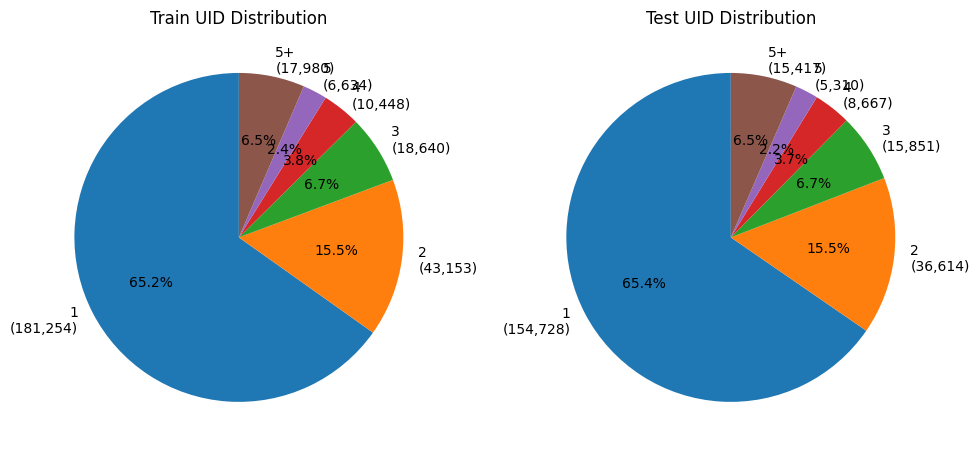

In [125]:
import matplotlib.pyplot as plt

def get_uid_counts(uid_summary):
    return [
        (uid_summary['Transactions'] == 1).sum(),
        (uid_summary['Transactions'] == 2).sum(),
        (uid_summary['Transactions'] == 3).sum(),
        (uid_summary['Transactions'] == 4).sum(),
        (uid_summary['Transactions'] == 5).sum(),
        (uid_summary['Transactions'] > 5).sum()
    ]

train_counts = get_uid_counts(uid_summary)
test_counts = get_uid_counts(test_uid_summary)

train_labels = [
    f'1\n({train_counts[0]:,})',
    f'2\n({train_counts[1]:,})',
    f'3\n({train_counts[2]:,})',
    f'4\n({train_counts[3]:,})',
    f'5\n({train_counts[4]:,})',
    f'5+\n({train_counts[5]:,})'
]

test_labels = [
    f'1\n({test_counts[0]:,})',
    f'2\n({test_counts[1]:,})',
    f'3\n({test_counts[2]:,})',
    f'4\n({test_counts[3]:,})',
    f'5\n({test_counts[4]:,})',
    f'5+\n({test_counts[5]:,})'
]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Train
axes[0].pie(
    train_counts,
    labels=train_labels,
    autopct='%1.1f%%',
    startangle=90
)
axes[0].set_title('Train UID Distribution')

# Test
axes[1].pie(
    test_counts,
    labels=test_labels,
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title('Test UID Distribution')

plt.tight_layout()
plt.show()

In [126]:
train_num_uids = df.groupby(uid_cols, dropna=False).ngroups
test_num_uids = test_df.groupby(uid_cols, dropna=False).ngroups

print(f"Train UIDs: {train_num_uids:,}")
print(f"Test UIDs:  {test_num_uids:,}")

Train UIDs: 278,109
Test UIDs:  236,587


In [127]:
features = [
    'Starting_day',
    # 'TransactionDT_day',
    'TransactionAmt',
    'V307',
    'TransactionDT_date',
    'TransactionDT',
    'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8',
    'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15',
    'ProductCD',
    'P_emaildomain',
    'R_emaildomain',
    'addr1',
    'addr2',
    'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7',
    'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14',
    'id_30', 'id_31', 'id_32', 'id_33',
    'DeviceType',
    'DeviceInfo',
    'card1', 'card2', 'card3', 'card4', 'card5', 'card6'
]

In [128]:
# -------- TRAIN --------
row = uid_summary.iloc[50]

mask = (df[uid_cols] == row[uid_cols]).all(axis=1)

train_result = (
    df.loc[mask, features]
      .sort_values(['P_emaildomain', 'TransactionDT'])
      .copy()
)

train_result['Cum_TransactionAmt'] = train_result['TransactionAmt'].cumsum()

cols = train_result.columns.tolist()
cols.insert(
    cols.index('TransactionAmt') + 1,
    cols.pop(cols.index('Cum_TransactionAmt'))
)

train_result = train_result[cols]

print("Train")
display(train_result)


# -------- TEST --------
test_mask = (test_df[uid_cols] == row[uid_cols]).all(axis=1)

test_result = (
    test_df.loc[test_mask, features]
           .sort_values(['P_emaildomain', 'TransactionDT'])
           .copy()
)

test_result['Cum_TransactionAmt'] = test_result['TransactionAmt'].cumsum()

cols = test_result.columns.tolist()
cols.insert(
    cols.index('TransactionAmt') + 1,
    cols.pop(cols.index('Cum_TransactionAmt'))
)

test_result = test_result[cols]

print("Test")
display(test_result)

Train


,Starting_day,TransactionAmt,Cum_TransactionAmt,V307,TransactionDT_date,TransactionDT,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,ProductCD,P_emaildomain,R_emaildomain,addr1,addr2,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,id_30,id_31,id_32,id_33,DeviceType,DeviceInfo,card1,card2,card3,card4,card5,card6


Test


,Starting_day,TransactionAmt,Cum_TransactionAmt,V307,TransactionDT_date,TransactionDT,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,ProductCD,P_emaildomain,R_emaildomain,addr1,addr2,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,id_30,id_31,id_32,id_33,DeviceType,DeviceInfo,card1,card2,card3,card4,card5,card6


In [129]:
df['UID'] = (
    df.groupby(uid_cols, sort=False, dropna=False)
      .ngroup()
      .astype(np.int32)
)

test_df['UID'] = (
    test_df.groupby(uid_cols, sort=False, dropna=False)
           .ngroup()
           .astype(np.int32)
)

In [130]:
for dataset in [df, test_df]:

    prev_sum = (
        dataset.groupby('UID')['TransactionAmt']
               .cumsum()
               .groupby(dataset['UID'])
               .shift(fill_value=0)
    )

    prev_count = (
        dataset.groupby('UID')
               .cumcount()
    )

    dataset['TransactionAmt_UID_mean'] = (
        prev_sum / prev_count.replace(0, np.nan)
    )

In [131]:
for dataset in [df, test_df]:

    # Previous cumulative sum
    prev_sum = (
        dataset.groupby('UID')['TransactionAmt']
               .cumsum()
               .groupby(dataset['UID'])
               .shift(fill_value=0)
    )

    # Previous cumulative sum of squares
    prev_sum_sq = (
        (dataset['TransactionAmt'] ** 2)
        .groupby(dataset['UID'])
        .cumsum()
        .groupby(dataset['UID'])
        .shift(fill_value=0)
    )

    # Number of previous transactions
    prev_count = dataset.groupby('UID').cumcount()

    # Historical variance
    variance = (
        prev_sum_sq - (prev_sum ** 2) / prev_count.replace(0, np.nan)
    ) / (prev_count - 1)

    # std = sqrt(var)
    dataset['TransactionAmt_UID_std'] = (
        np.sqrt(variance.clip(lower=0))
          .fillna(0)
    )

In [132]:
for dataset in [df, test_df]:

    dataset['TransactionAmt_UID_ratio'] = (
        dataset['TransactionAmt']
        /
        dataset['TransactionAmt_UID_mean'].replace(0, np.nan)
    )

In [133]:
df = df.copy()
test_df = test_df.copy()

In [134]:
for dataset in [df, test_df]:

    dataset['TransactionAmt_UID_log_ratio'] = np.where(
        dataset['TransactionAmt_UID_ratio'] > 0,
        np.log(dataset['TransactionAmt_UID_ratio']),
        np.nan
    )

In [135]:
for dataset in [df, test_df]:

    dataset['TransactionAmt_UID_zscore'] = (
        (
            dataset['TransactionAmt']
            - dataset['TransactionAmt_UID_mean']
        )
        /
        dataset['TransactionAmt_UID_std']
               .replace(0, np.nan)
    )

In [136]:
df=df.copy()

In [137]:
from scipy.stats import percentileofscore

def previous_percentile(x):

    history = []
    ans = []

    for v in x:

        if len(history) == 0:
            ans.append(np.nan)
        else:
            ans.append(
                percentileofscore(
                    history,
                    v,
                    kind="weak"
                ) / 100
            )

        history.append(v)

    return pd.Series(ans, index=x.index)


for dataset in [df, test_df]:

    dataset['TransactionAmt_UID_percentile'] = (
        dataset.groupby('UID', sort=False)['TransactionAmt']
               .apply(previous_percentile)
               .reset_index(level=0, drop=True)
    )

In [138]:
for name, dataset in [('Train', df), ('Test', test_df)]:

    print(f'{name}')
    print("Unique values:", dataset['TransactionAmt_UID_percentile'].nunique(dropna=True))
    print("NaNs:", dataset['TransactionAmt_UID_percentile'].isna().sum())
    print()

Train
Unique values: 3336
NaNs: 278109

Test
Unique values: 1957
NaNs: 236587



In [139]:
for dataset in [df, test_df]:
    dataset['TransactionAmt_dollars'] = np.floor(dataset['TransactionAmt'])

In [140]:
for dataset in [df, test_df]:
    dataset['TransactionAmt_cents'] = (
        dataset['TransactionAmt']
        - np.floor(dataset['TransactionAmt'])
    ).round(2)

In [141]:
df=df.copy()

In [142]:
def previous_nunique(x):

    seen = set()
    ans = []

    for v in x:

        ans.append(len(seen))

        seen.add(v)

    return pd.Series(ans, index=x.index)


for dataset in [df, test_df]:

    dataset['uid_cents_ct'] = (
        dataset.groupby('UID', sort=False)['TransactionAmt_cents']
               .apply(previous_nunique)
               .reset_index(level=0, drop=True)
    )

In [143]:
for dataset in [df, test_df]:

    dataset['TransactionDT_hour'] = (
        ((dataset['TransactionDT_date'] % 1) * 24)
    ).astype(int)

In [144]:
for dataset in [df, test_df]:

    angle = 2 * np.pi * dataset['TransactionDT_hour'] / 24

    dataset['hour_sin'] = np.sin(angle)
    dataset['hour_cos'] = np.cos(angle)

In [145]:
df=df.copy()

In [146]:
for dataset in [df, test_df]:

    prev_sin_sum = (
        dataset.groupby('UID')['hour_sin']
               .cumsum()
               .groupby(dataset['UID'])
               .shift(fill_value=0)
    )

    prev_cos_sum = (
        dataset.groupby('UID')['hour_cos']
               .cumsum()
               .groupby(dataset['UID'])
               .shift(fill_value=0)
    )

    prev_count = dataset.groupby('UID').cumcount()

    sin_mean = prev_sin_sum / prev_count.replace(0, np.nan)
    cos_mean = prev_cos_sum / prev_count.replace(0, np.nan)

    mean_angle = np.arctan2(sin_mean, cos_mean)

    dataset['TransactionDT_hour_UID_mean'] = (
        mean_angle * 24 / (2 * np.pi)
    ) % 24

In [147]:
for dataset in [df, test_df]:

    prev_sin_sum = (
        dataset.groupby('UID')['hour_sin']
               .cumsum()
               .groupby(dataset['UID'])
               .shift(fill_value=0)
    )

    prev_cos_sum = (
        dataset.groupby('UID')['hour_cos']
               .cumsum()
               .groupby(dataset['UID'])
               .shift(fill_value=0)
    )

    prev_count = dataset.groupby('UID').cumcount()

    sin_mean = prev_sin_sum / prev_count.replace(0, np.nan)
    cos_mean = prev_cos_sum / prev_count.replace(0, np.nan)

    dataset['TransactionDT_hour_UID_consistency'] = np.sqrt(
        sin_mean**2 + cos_mean**2
    )

In [148]:
for dataset in [df, test_df]:

    delta = (
        (
            dataset['TransactionDT_hour']
            - dataset['TransactionDT_hour_UID_mean']
            + 12
        ) % 24
    ) - 12

    dataset['TransactionDT_hour_UID_diff'] = np.abs(delta)

In [149]:
for dataset in [df, test_df]:
    dataset.drop(
        columns=['hour_sin', 'hour_cos'],
        inplace=True
    )

In [150]:
df=df.copy()

In [151]:
# M1-M9 excluding M4
m_cols = ['M1', 'M2', 'M3', 'M5', 'M6', 'M7', 'M8', 'M9']

for dataset in [df, test_df]:

    for col in m_cols:

        # Match indicator: T=1, F=0, NaN stays NaN
        dataset[col + '_match'] = np.where(
            dataset[col] == 'T',
            1,
            np.where(dataset[col] == 'F', 0, np.nan)
        )

        # Missing indicator: NaN=1, otherwise 0
        dataset[col + '_missing'] = dataset[col].isna().astype(np.int8)

In [152]:
for dataset in [df, test_df]:

    prev_txn_count = (
        dataset.groupby('UID')
               .cumcount()
    )

In [153]:
df=df.copy()

In [154]:
# Feature 1. Historical UID Match Rate (Leakage-Free)

for dataset in [df, test_df]:

    for col in m_cols:

        match = dataset[col + '_match']

        # Previous cumulative number of matches
        prev_match_sum = (
            match.fillna(0)
                 .groupby(dataset['UID'])
                 .cumsum()
                 .groupby(dataset['UID'])
                 .shift(fill_value=0)
        )

        # Previous number of observed (non-missing) values
        prev_observed = (
            match.notna()
                 .astype(np.int32)
                 .groupby(dataset['UID'])
                 .cumsum()
                 .groupby(dataset['UID'])
                 .shift(fill_value=0)
        )

        # Historical match rate
        dataset[col + '_UID_match_rate'] = (
            prev_match_sum /
            prev_observed.replace(0, np.nan)
        )

In [155]:
# Feature 2. Historical Missing Rate (Leakage-Free)

for dataset in [df, test_df]:

    prev_txn_count = (
        dataset.groupby('UID')
               .cumcount()
    )

    for col in m_cols:

        prev_missing_sum = (
            dataset[col + '_missing']
                   .groupby(dataset['UID'])
                   .cumsum()
                   .groupby(dataset['UID'])
                   .shift(fill_value=0)
        )

        dataset[col + '_UID_missing_rate'] = (
            prev_missing_sum /
            prev_txn_count.replace(0, np.nan)
        )

In [156]:
df=df.copy()

In [157]:
# Feature 3. Running Mismatch Count (Leakage-Free)

for dataset in [df, test_df]:

    for col in m_cols:

        mismatch = (dataset[col] == 'F').astype(np.int8)

        dataset[col + '_UID_mismatch_count'] = (
            mismatch
            .groupby(dataset['UID'])
            .cumsum()
            .groupby(dataset['UID'])
            .shift(fill_value=0)
            .astype(np.int32)
        )

In [158]:
# Feature 4. Running Match Count (Leakage-Free)

for dataset in [df, test_df]:

    for col in m_cols:

        match = (dataset[col] == 'T').astype(np.int8)

        dataset[col + '_UID_match_count'] = (
            match
            .groupby(dataset['UID'])
            .cumsum()
            .groupby(dataset['UID'])
            .shift(fill_value=0)
            .astype(np.int32)
        )

In [159]:
df=df.copy()

In [160]:
# Feature 5. Running Missing Count (Leakage-Free)

for dataset in [df, test_df]:

    for col in m_cols:

        missing = dataset[col + '_missing'].astype(np.int8)

        dataset[col + '_UID_missing_count'] = (
            missing
            .groupby(dataset['UID'])
            .cumsum()
            .groupby(dataset['UID'])
            .shift(fill_value=0)
            .astype(np.int32)
        )

In [161]:
for dataset in [df, test_df]:
    dataset.drop(
        columns=[f'{col}_match' for col in m_cols] +
                [f'{col}_missing' for col in m_cols],
        inplace=True
    )

In [162]:
df=df.copy()

In [163]:
nunique_cols = [
    'DeviceInfo',
    'DeviceType',
    'id_30_OS',
    'id_30_Version',
    'R_emaildomain',
]

for dataset in [df, test_df]:

    for col in nunique_cols:

        # Ignore NaNs
        valid = dataset[col].notna()

        # First appearance of a value within each UID
        first_seen = (
            valid &
            ~dataset.loc[valid]
                    .duplicated(subset=['UID', col])
                    .reindex(dataset.index, fill_value=False)
        )

        # Number of distinct values seen INCLUDING current row
        cum_unique = (
            first_seen.astype(np.int32)
                      .groupby(dataset['UID'])
                      .cumsum()
        )

        # Leakage-free: remove current row
        dataset[col + '_UID_nunique'] = (
            cum_unique
            .groupby(dataset['UID'])
            .shift(fill_value=0)
            .astype(np.int16)
        )

In [164]:
# Find all categorical columns from TRAIN
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Remove target if present
categorical_cols = [col for col in categorical_cols if col != 'isFraud']

# -----------------------
# Train CSV
# -----------------------
train_cv = df[categorical_cols + ['isFraud']].copy()
train_cv.to_csv('train_categorical_columns.csv', index=False)

# -----------------------
# Test CSV
# -----------------------
# Only keep columns that actually exist in test_df
test_cols = [col for col in categorical_cols if col in test_df.columns]

test_cv = test_df[test_cols].copy()
test_cv.to_csv('test_categorical_columns.csv', index=False)

print("Saved:")
print(" - train_categorical_columns.csv")
print(" - test_categorical_columns.csv")

Saved:
 - train_categorical_columns.csv
 - test_categorical_columns.csv


In [165]:
df.M1.head()

0      T
1    NaN
2      T
3    NaN
4    NaN
Name: M1, dtype: object

In [166]:
print("Train columns:")
print(df.columns.tolist())

print("\nTest columns:")
print(test_df.columns.tolist())

Train columns:
['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'V1', 'V3', 'V4', 'V6', 'V8', 'V11', 'V13', 'V14', 'V17', 'V20', 'V23', 'V26', 'V27', 'V30', 'V34', 'V36', 'V37', 'V40', 'V41', 'V44', 'V47', 'V48', 'V52', 'V54', 'V55', 'V56', 'V59', 'V62', 'V65', 'V67', 'V68', 'V70', 'V76', 'V78', 'V79', 'V80', 'V82', 'V86', 'V88', 'V89', 'V91', 'V98', 'V99', 'V104', 'V107', 'V108', 'V109', 'V111', 'V114', 'V115', 'V117', 'V118', 'V120', 'V121', 'V123', 'V124', 'V127', 'V129', 'V130', 'V131', 'V137', 'V138', 'V139', 'V142', 'V147', 'V155', 'V160', 'V162', 'V165', 'V166', 'V169', 'V171', 'V173', 'V174', '

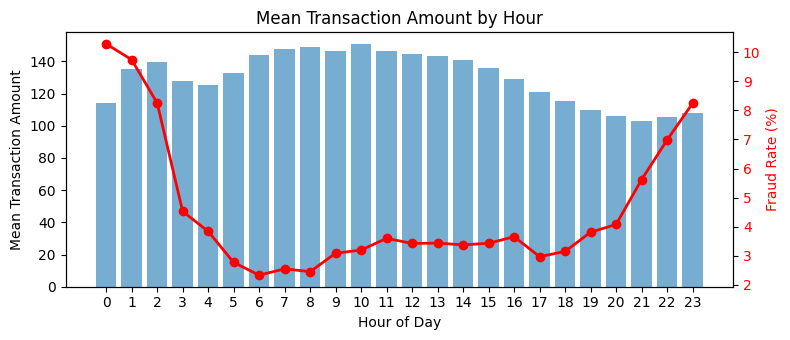

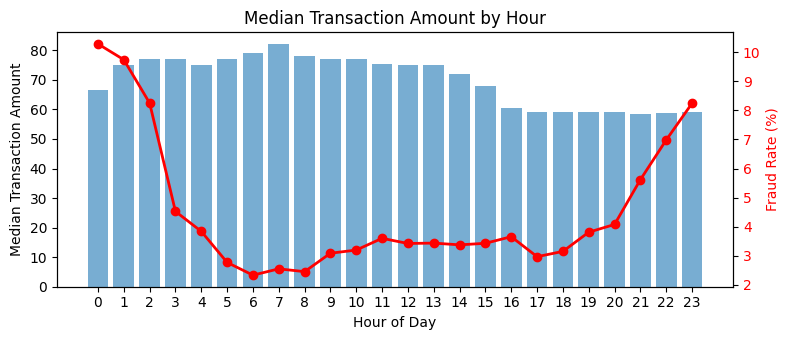

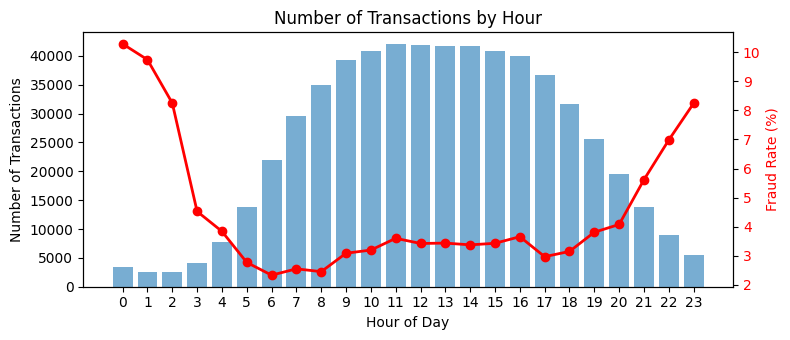

In [167]:
import matplotlib.pyplot as plt

# Aggregate by hour
hourly = (
    df.groupby("TransactionDT_hour")
      .agg(
          Mean_Amt=("TransactionAmt", "mean"),
          Median_Amt=("TransactionAmt", "median"),
          Transactions=("TransactionAmt", "size"),
          Fraud_Rate=("isFraud", "mean")
      )
      .reindex(range(24), fill_value=0)   # Ensure hours 0-23 are present
)

hourly["Fraud_Rate"] *= 100

plots = [
    ("Mean_Amt", "Mean Transaction Amount"),
    ("Median_Amt", "Median Transaction Amount"),
    ("Transactions", "Number of Transactions")
]

for col, title in plots:
    fig, ax1 = plt.subplots(figsize=(8, 3.5))

    # Bar plot
    ax1.bar(hourly.index, hourly[col], alpha=0.6)
    ax1.set_xlabel("Hour of Day")
    ax1.set_ylabel(title)
    ax1.set_xticks(range(24))

    # Fraud rate line
    ax2 = ax1.twinx()
    ax2.plot(
        hourly.index,
        hourly["Fraud_Rate"],
        color="red",
        marker="o",
        linewidth=2
    )

    ax2.set_ylabel("Fraud Rate (%)", color="red")
    ax2.tick_params(axis="y", labelcolor="red")

    plt.title(f"{title} by Hour")
    plt.tight_layout()
    plt.show()

In [168]:
for dataset in [df, test_df]:

    dataset['is_quiet_hours'] = (
        dataset['TransactionDT_hour']
        .between(4, 10)
        .astype(np.int8)
    )

# Sanity check (train only, since test has no isFraud)
print(
    df.groupby('is_quiet_hours')['isFraud']
      .agg(['size', 'mean'])
      .round(4)
)

                  size    mean
is_quiet_hours                
0               402323  0.0381
1               188217  0.0283


In [169]:
df.is_quiet_hours

0         0
1         0
2         0
3         0
4         0
         ..
590535    0
590536    0
590537    0
590538    0
590539    0
Name: is_quiet_hours, Length: 590540, dtype: int8

In [170]:
d_cols = ["D4", "D6", "D10", "D11", "D12", "D13", "D14", "D15"]

for dataset in [df, test_df]:

    for col in d_cols:

        diff = dataset["TransactionDT_date"] - dataset[col]

        dataset[col + "n"] = np.where(
            diff >= 0,
            np.where(
                (diff - np.floor(diff)) > 0.7,
                np.floor(diff) + 1,
                np.floor(diff)
            ),
            np.where(
                (diff - np.ceil(diff)) > -0.3,
                np.ceil(diff),
                np.floor(diff)
            )
        )

        # Preserve missing values
        dataset.loc[dataset[col].isna(), col + "n"] = np.nan

        # Nullable integer type
        dataset[col + "n"] = dataset[col + "n"].astype("Int64")

    # Drop the original D columns after creating the new ones
    dataset.drop(columns=d_cols, inplace=True)

In [171]:
CAT_STRING = [
    'ProductCD', 'card4', 'card6',
    'P_emaildomain', 'R_emaildomain',
    'P_provider', 'R_provider', 'P_suffix', 'R_suffix',
    'P_provider_group', 'R_provider_group',
    'M1','M2','M3','M4','M5','M6','M7','M8','M9',
    'id_12','id_15','id_16','id_23','id_27','id_28','id_29',
    'id_30','id_31','id_33','id_34','id_35','id_36','id_37','id_38',
    'DeviceType','DeviceInfo',
    'id_30_OS','id_30_Version',
]

# Integer-typed columns that are actually CATEGORIES, not quantities.
# card1=13926 is not "bigger" than card1=2755 — it's a different card.
CAT_NUMERIC = ['card1', 'card2', 'card3', 'card5', 'addr1', 'addr2']

# Keep only what actually exists (you may have dropped some during EDA)
CAT_STRING  = [c for c in CAT_STRING  if c in df.columns]
CAT_NUMERIC = [c for c in CAT_NUMERIC if c in df.columns]
ALL_CAT = CAT_STRING + CAT_NUMERIC

print(f"String categoricals : {len(CAT_STRING)}")
print(f"Numeric categoricals: {len(CAT_NUMERIC)}")

String categoricals : 39
Numeric categoricals: 6


In [172]:
train_cols = set(df.columns) - {'isFraud'}
test_cols  = set(test_df.columns)

print("In train, missing from test:", sorted(train_cols - test_cols))
print("In test, missing from train:", sorted(test_cols - train_cols))

In train, missing from test: ['D8_frac', 'D8_int', 'hour_frac']
In test, missing from train: ['weekday']


In [173]:
# ============================================================
# STEP 0A: ORDINAL ENCODING
# Fit on train+test COMBINED so identical strings get identical integers.
# ============================================================

MISSING_TOKEN = '__missing__'

# Store the mappings so we can inspect / reverse them later
encoding_maps = {}

for col in CAT_STRING:
    # 1. Stack train and test values for this column
    combined = pd.concat([df[col], test_df[col]], axis=0)

    # 2. NaN becomes an EXPLICIT category, not a null.
    #    Your EDA established missingness is informative here — we want the model
    #    to be able to split on "this value was absent" as a category in its own right.
    combined = combined.fillna(MISSING_TOKEN).astype(str)

    # 3. Build the lookup table: sorted unique values -> 0, 1, 2, ...
    categories = sorted(combined.unique())
    mapping = {v: i for i, v in enumerate(categories)}
    encoding_maps[col] = mapping

    # 4. Apply the SAME mapping to both
    df[col + '_enc'] = df[col].fillna(MISSING_TOKEN).astype(str).map(mapping).astype('int32')
    test_df[col + '_enc'] = test_df[col].fillna(MISSING_TOKEN).astype(str).map(mapping).astype('int32')

print(f"Encoded {len(CAT_STRING)} string columns")
print(f"Example — P_provider_group has {len(encoding_maps['P_provider_group'])} categories")

Encoded 39 string columns
Example — P_provider_group has 25 categories


/tmp/ipykernel_58/847229890.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_df[col + '_enc'] = test_df[col].fillna(MISSING_TOKEN).astype(str).map(mapping).astype('int32')


In [174]:
for col in CAT_NUMERIC:
    df[col + '_enc'] = df[col].fillna(-999).astype('int32')
    test_df[col + '_enc'] = test_df[col].fillna(-999).astype('int32')

print(f"Prepared {len(CAT_NUMERIC)} numeric categoricals")

Prepared 6 numeric categoricals


/tmp/ipykernel_58/3204020926.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_df[col + '_enc'] = test_df[col].fillna(-999).astype('int32')
/tmp/ipykernel_58/3204020926.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_df[col + '_enc'] = test_df[col].fillna(-999).astype('int32')
/tmp/ipykernel_58/3204020926.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=

In [175]:
df=df.copy()
test_df=test_df.copy()

In [176]:
# ============================================================
# STEP 0C: VERIFY the encoding is consistent
# This check catches the single most dangerous silent bug.
# ============================================================

col = 'P_provider_group'
for test_val in ['google', 'microsoft', 'yahoo']:
    if test_val in encoding_maps[col].values() or test_val in encoding_maps[col]:
        code = encoding_maps[col][test_val]
        tr_ok = (df.loc[df[col] == test_val, col + '_enc'] == code).all()
        te_ok = (test_df.loc[test_df[col] == test_val, col + '_enc'] == code).all()
        print(f"  '{test_val}' -> {code} | train OK: {tr_ok} | test OK: {te_ok}")

# Also confirm no unmapped values slipped through
for c in CAT_STRING:
    assert df[c + '_enc'].isna().sum() == 0, f"Unmapped values in train {c}"
    assert test_df[c + '_enc'].isna().sum() == 0, f"Unmapped values in test {c}"
print("\nAll values mapped in both train and test.")

  'google' -> 12 | train OK: True | test OK: True
  'microsoft' -> 14 | train OK: True | test OK: True
  'yahoo' -> 24 | train OK: True | test OK: True

All values mapped in both train and test.


In [177]:
# ============================================================
# STEP 0E: Lock the feature list
# ============================================================

EXCLUDE = [
    'isFraud',           # target
    'TransactionID',     # row counter, pure file artifact
    'TransactionDT',     # raw clock, top drift feature
    'TransactionDT_date',
    'month', 'day', 'hour',     # used for splitting only; test values are unseen
    'UID',               # memorising specific clients doesn't generalise.
                         # We keep its AGGREGATES, not the ID itself.
]

# The raw string versions are replaced by their _enc counterparts
EXCLUDE += CAT_STRING

# Anything adversarial validation flags later gets added here
DROP_FROM_ADVERSARIAL = []
EXCLUDE += DROP_FROM_ADVERSARIAL

FEATURES = [c for c in df.columns
            if c not in EXCLUDE and c in test_df.columns]

# The encoded categorical names, for the models that need to know
CAT_FEATURES_ENC = [c + '_enc' for c in ALL_CAT if c + '_enc' in FEATURES]

print(f"Total features    : {len(FEATURES)}")
print(f"Of which categorical: {len(CAT_FEATURES_ENC)}")

# Final safety checks
assert 'isFraud' not in FEATURES
assert all(c in test_df.columns for c in FEATURES)
leftover = df[FEATURES].select_dtypes(include=['object']).columns.tolist()
assert len(leftover) == 0, f"Unencoded object columns remain: {leftover}"
print("Feature list is clean.")

Total features    : 333
Of which categorical: 45
Feature list is clean.


In [178]:
for d in [df, test_df]:
    d.drop(columns=["hour", "day"], inplace=True)

In [179]:
print(df.columns.tolist())

['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D5', 'D7', 'D8', 'D9', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'V1', 'V3', 'V4', 'V6', 'V8', 'V11', 'V13', 'V14', 'V17', 'V20', 'V23', 'V26', 'V27', 'V30', 'V34', 'V36', 'V37', 'V40', 'V41', 'V44', 'V47', 'V48', 'V52', 'V54', 'V55', 'V56', 'V59', 'V62', 'V65', 'V67', 'V68', 'V70', 'V76', 'V78', 'V79', 'V80', 'V82', 'V86', 'V88', 'V89', 'V91', 'V98', 'V99', 'V104', 'V107', 'V108', 'V109', 'V111', 'V114', 'V115', 'V117', 'V118', 'V120', 'V121', 'V123', 'V124', 'V127', 'V129', 'V130', 'V131', 'V137', 'V138', 'V139', 'V142', 'V147', 'V155', 'V160', 'V162', 'V165', 'V166', 'V169', 'V171', 'V173', 'V174', 'V175', 'V176', 'V180', 'V181', 'V185', 'V188', 'V194', 'V198', 'V201'

In [180]:
month_summary = df.groupby('month').agg(
    n_rows=('isFraud', 'size'),
    n_fraud=('isFraud', 'sum'),
    fraud_rate=('isFraud', 'mean'),
).round(4)

print(month_summary.to_string())
print(f"\nUnique months: {df['month'].nunique()}")
print(f"Smallest: {month_summary['n_rows'].min():,}  Largest: {month_summary['n_rows'].max():,}")

       n_rows  n_fraud  fraud_rate
month                             
0      130968     3243      0.0248
1       89838     3627      0.0404
2       91768     3700      0.0403
3       98027     3849      0.0393
4       85303     2962      0.0347
5       86525     2943      0.0340
6        8111      339      0.0418

Unique months: 7
Smallest: 8,111  Largest: 130,968


In [181]:
import numpy as np
from sklearn.model_selection import GroupKFold

df.loc[df['month'] == 6, 'month'] = 5
y = df['isFraud'].copy()

N_SPLITS = df['month'].nunique()
groups = df['month'].values
splits_A = list(GroupKFold(n_splits=N_SPLITS).split(df, y, groups=groups))

print('Fold | train rows | val rows | val month | val fraud rate')
print('-' * 60)
for i, (tr_idx, va_idx) in enumerate(splits_A):
    tr_m, va_m = set(df['month'].iloc[tr_idx]), set(df['month'].iloc[va_idx])
    assert not (tr_m & va_m), f'LEAK in fold {i}: {tr_m & va_m}'
    print(f'{i:>4} | {len(tr_idx):>10,} | {len(va_idx):>8,} | {str(sorted(va_m)):<9} | {y.iloc[va_idx].mean():.4f}')

LAST_MONTH = df['month'].max()
holdout_va = np.where(df['month'] == LAST_MONTH)[0]
holdout_tr = np.where(df['month'] < LAST_MONTH)[0]
split_B = (holdout_tr, holdout_va)

print(f'\nSplit B train: {len(holdout_tr):,} | val: {len(holdout_va):,} (month {LAST_MONTH})')
print(f'Split B val fraud rate: {y.iloc[holdout_va].mean():.4f}')

Fold | train rows | val rows | val month | val fraud rate
------------------------------------------------------------
   0 |    459,572 |  130,968 | [0]       | 0.0248
   1 |    492,513 |   98,027 | [3]       | 0.0393
   2 |    495,904 |   94,636 | [5]       | 0.0347
   3 |    498,772 |   91,768 | [2]       | 0.0403
   4 |    500,702 |   89,838 | [1]       | 0.0404
   5 |    505,237 |   85,303 | [4]       | 0.0347

Split B train: 495,904 | val: 94,636 (month 5)
Split B val fraud rate: 0.0347


In [182]:
import time
from sklearn.metrics import roc_auc_score, average_precision_score
import lightgbm as lgb

def run_cv(model_factory, X, y, splits, X_test=None, model_name='model',
           model_type='sklearn', cat_features=None, verbose=True):
    oof = np.zeros(len(X))
    test_pred = np.zeros(len(X_test)) if X_test is not None else None
    fold_scores, models, best_iters = [], [], []
    t0 = time.time()

    for fold, (tr_idx, va_idx) in enumerate(splits):
        X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
        X_va, y_va = X.iloc[va_idx], y.iloc[va_idx]
        model = model_factory()

        if model_type == 'xgb':
            model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
            best_iters.append(getattr(model, 'best_iteration', None))
        elif model_type == 'lgb':
            model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], eval_metric='auc',
                      callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)])
            best_iters.append(model.best_iteration_)
        elif model_type == 'cat':
            model.fit(X_tr, y_tr, eval_set=(X_va, y_va),
                      cat_features=cat_features, use_best_model=True, verbose=False)
            best_iters.append(model.get_best_iteration())
        else:
            model.fit(X_tr, y_tr)
            best_iters.append(None)

        oof[va_idx] = model.predict_proba(X_va)[:, 1]
        score = roc_auc_score(y_va, oof[va_idx])
        fold_scores.append(score)
        models.append(model)

        if X_test is not None:
            test_pred += model.predict_proba(X_test)[:, 1] / len(splits)

        if verbose:
            bi = f' | trees={best_iters[-1]}' if best_iters[-1] else ''
            print(f'  fold {fold}: AUC = {score:.5f}{bi}')

    oof_auc = roc_auc_score(y, oof)
    if verbose:
        print(f'\n  {model_name}')
        print(f'  Mean fold AUC : {np.mean(fold_scores):.5f} (+/- {np.std(fold_scores):.5f})')
        print(f'  Overall OOF   : {oof_auc:.5f}')
        print(f'  PR-AUC        : {average_precision_score(y, oof):.5f}')
        print(f'  Time          : {(time.time()-t0)/60:.1f} min\n')

    return {'oof': oof, 'test_pred': test_pred, 'fold_scores': fold_scores,
            'oof_auc': oof_auc, 'models': models, 'name': model_name, 'best_iters': best_iters}

results = {}
print('Harness ready.')

Harness ready.


In [183]:
train_cols = set(df.columns) - {'isFraud'}
test_cols = set(test_df.columns)

print("In train, missing from test:", sorted(train_cols - test_cols))
print("In test, missing from train:", sorted(test_cols - train_cols))

EXCLUDE_ADV = ['isFraud', 'TransactionID']
adv_features = [c for c in df.columns if c not in EXCLUDE_ADV and c in test_df.columns]

print(f"\nAdversarial feature count: {len(adv_features)}")

In train, missing from test: ['D8_frac', 'D8_int', 'hour_frac']
In test, missing from train: ['weekday']

Adversarial feature count: 376


In [184]:
print(df.columns.tolist())

['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D5', 'D7', 'D8', 'D9', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'V1', 'V3', 'V4', 'V6', 'V8', 'V11', 'V13', 'V14', 'V17', 'V20', 'V23', 'V26', 'V27', 'V30', 'V34', 'V36', 'V37', 'V40', 'V41', 'V44', 'V47', 'V48', 'V52', 'V54', 'V55', 'V56', 'V59', 'V62', 'V65', 'V67', 'V68', 'V70', 'V76', 'V78', 'V79', 'V80', 'V82', 'V86', 'V88', 'V89', 'V91', 'V98', 'V99', 'V104', 'V107', 'V108', 'V109', 'V111', 'V114', 'V115', 'V117', 'V118', 'V120', 'V121', 'V123', 'V124', 'V127', 'V129', 'V130', 'V131', 'V137', 'V138', 'V139', 'V142', 'V147', 'V155', 'V160', 'V162', 'V165', 'V166', 'V169', 'V171', 'V173', 'V174', 'V175', 'V176', 'V180', 'V181', 'V185', 'V188', 'V194', 'V198', 'V201'

In [185]:
test_df['D8_int'] = np.floor(test_df['D8'])
test_df['D8_frac'] = test_df['D8'] - test_df['D8_int']

print(test_df[['D8', 'D8_int', 'D8_frac']].head())

   D8  D8_int  D8_frac
0 NaN     NaN      NaN
1 NaN     NaN      NaN
2 NaN     NaN      NaN
3 NaN     NaN      NaN
4 NaN     NaN      NaN


In [186]:
train_cols = set(df.columns) - {'isFraud'}
test_cols = set(test_df.columns)

print("In train, missing from test:", sorted(train_cols - test_cols))
print("In test, missing from train:", sorted(test_cols - train_cols))

In train, missing from test: ['hour_frac']
In test, missing from train: ['weekday']


In [187]:
if 'D9' in df.columns:
    df = df.drop(columns=['D9'])
print('D9' in df.columns)

False


In [188]:
check = (df['TransactionDT_hour'] / 24.0 - df['hour_frac']).abs()
print(check.describe())
print(df[['TransactionDT_hour', 'hour_frac']].head())

count    590540.000000
mean          0.400729
std           0.174571
min           0.291667
25%           0.291667
50%           0.291667
75%           0.666667
max           0.708333
dtype: float64
   TransactionDT_hour  hour_frac
0                  16        0.0
1                  16        0.0
2                  16        0.0
3                  16        0.0
4                  16        0.0


In [189]:
if 'hour_frac' in df.columns:
    df = df.drop(columns=['hour_frac'])
print('hour_frac' in df.columns)

False


In [190]:
train_cols = set(df.columns) - {'isFraud'}
test_cols = set(test_df.columns)

print("In train, missing from test:", sorted(train_cols - test_cols))
print("In test, missing from train:", sorted(test_cols - train_cols))

In train, missing from test: []
In test, missing from train: ['D9', 'weekday']


In [191]:
COLS_TO_DROP = ['D1', 'D2', 'D4', 'D6', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'TransactionDT', 'month']

df = df.drop(columns=[c for c in COLS_TO_DROP if c in df.columns])
test_df = test_df.drop(columns=[c for c in COLS_TO_DROP if c in test_df.columns])

print("Remaining:", [c for c in COLS_TO_DROP if c in df.columns or c in test_df.columns])

Remaining: []


In [192]:
import gc
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import lightgbm as lgb

EXCLUDE_ADV = ['isFraud', 'TransactionID', 'TransactionDT_date', 'Starting_day', 'UID']
obj_cols = df.select_dtypes(include=['object']).columns.tolist()
v_cols = [c for c in df.columns if c.startswith('V')]

adv_features = [c for c in df.columns
                if c not in EXCLUDE_ADV
                and c not in obj_cols
                and c not in v_cols
                and c in test_df.columns]

print(f"Adversarial features: {len(adv_features)}")

N = 20_000
adv_X = pd.concat(
    [df[adv_features].sample(n=N, random_state=42),
     test_df[adv_features].sample(n=N, random_state=42)],
    axis=0, ignore_index=True
)
adv_y = pd.Series([0]*N + [1]*N)

adv_splits = list(StratifiedKFold(n_splits=3, shuffle=True, random_state=42).split(adv_X, adv_y))
adv_oof = np.zeros(len(adv_X))
imp = pd.DataFrame(index=adv_X.columns)

for i, (tr, va) in enumerate(adv_splits):
    m = lgb.LGBMClassifier(n_estimators=150, learning_rate=0.05, num_leaves=31,
                           random_state=42, verbose=-1, n_jobs=-1)
    m.fit(adv_X.iloc[tr], adv_y.iloc[tr])
    adv_oof[va] = m.predict_proba(adv_X.iloc[va])[:, 1]
    imp[f'f{i}'] = m.feature_importances_

adv_auc = roc_auc_score(adv_y, adv_oof)
imp['mean'] = imp.mean(axis=1)
top20 = imp['mean'].sort_values(ascending=False).head(20)

print(f"\nADVERSARIAL AUC: {adv_auc:.5f}\n")
for r, (f, v) in enumerate(top20.items(), 1):
    print(f"{r:>2}. {f:<30} {v:>7.1f}")

del adv_X, adv_y
gc.collect()

Adversarial features: 193

ADVERSARIAL AUC: 0.98494

 1. D4n                              374.0
 2. D11n                             333.7
 3. D10n                             293.7
 4. D15n                             272.3
 5. C13                              265.7
 6. D5                               243.7
 7. id_31_enc                        242.3
 8. dist1                            129.3
 9. D3                               109.3
10. M7_UID_missing_rate              108.0
11. id_13                             96.7
12. C11                               96.0
13. C12                               81.0
14. M1_UID_missing_rate               72.0
15. M1_UID_missing_count              60.7
16. D14n                              59.0
17. C9                                57.3
18. TransactionDT_hour_UID_mean       51.3
19. C6                                47.3
20. card5                             47.0


21851

In [193]:
for c in ['D4n', 'D10n', 'D11n', 'D14n', 'D15n']:
    if c in df.columns:
        tr_mean = df[c].mean()
        te_mean = test_df[c].mean()
        print(f"{c:<8} train mean: {tr_mean:>10.2f}   test mean: {te_mean:>10.2f}   diff: {te_mean - tr_mean:>10.2f}")

D4n      train mean:     -50.76   test mean:     138.45   diff:     189.21
D10n     train mean:     -35.21   test mean:     152.81   diff:     188.02
D11n     train mean:     -45.75   test mean:      85.25   diff:     131.00
D14n     train mean:      25.73   test mean:     281.93   diff:     256.20
D15n     train mean:     -75.03   test mean:     105.77   diff:     180.80


In [194]:
print(df[['D3', 'D5']].describe())
print(test_df[['D3', 'D5']].describe())

                  D3             D5
count  327662.000000  280699.000000
mean       28.343348      42.335964
std        62.393723      88.994080
min         0.000000       0.000000
25%         1.000000       1.000000
50%         8.000000      10.000000
75%        27.000000      32.000000
max       819.000000     819.000000
                  D3             D5
count  303549.000000  282316.000000
mean       33.394726      50.977753
std        82.558319     116.816566
min         0.000000       0.000000
25%         1.000000       0.000000
50%         7.000000       8.000000
75%        28.000000      34.000000
max      1076.000000    1088.000000


In [195]:
for c in ['C13', 'C11', 'C12', 'C9', 'C2', 'C6', 'C1']:
    if c in df.columns:
        print(f"{c:<5} train mean: {df[c].mean():>10.2f}   test mean: {test_df[c].mean():>10.2f}")

C13   train mean:      32.54   test mean:      27.82
C11   train mean:      10.24   test mean:       7.48
C12   train mean:       4.08   test mean:       2.65
C9    train mean:       4.48   test mean:       4.41
C2    train mean:      15.27   test mean:      10.71
C6    train mean:       9.07   test mean:       6.85
C1    train mean:      14.09   test mean:      10.09


In [196]:
BROKEN_DETRENDED = ['D4n', 'D10n', 'D11n', 'D14n', 'D15n']

df = df.drop(columns=[c for c in BROKEN_DETRENDED if c in df.columns])
test_df = test_df.drop(columns=[c for c in BROKEN_DETRENDED if c in test_df.columns])

print("Remaining:", [c for c in BROKEN_DETRENDED if c in df.columns or c in test_df.columns])

Remaining: []


In [197]:
import gc
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import lightgbm as lgb

EXCLUDE_ADV = ['isFraud', 'TransactionID', 'TransactionDT_date', 'Starting_day', 'UID']
obj_cols = df.select_dtypes(include=['object']).columns.tolist()
v_cols = [c for c in df.columns if c.startswith('V')]

adv_features = [c for c in df.columns
                if c not in EXCLUDE_ADV
                and c not in obj_cols
                and c not in v_cols
                and c in test_df.columns]

print(f"Adversarial features: {len(adv_features)}")

N = 20_000
adv_X = pd.concat(
    [df[adv_features].sample(n=N, random_state=42),
     test_df[adv_features].sample(n=N, random_state=42)],
    axis=0, ignore_index=True
)
adv_y = pd.Series([0]*N + [1]*N)

adv_splits = list(StratifiedKFold(n_splits=3, shuffle=True, random_state=42).split(adv_X, adv_y))
adv_oof = np.zeros(len(adv_X))
imp = pd.DataFrame(index=adv_X.columns)

for i, (tr, va) in enumerate(adv_splits):
    m = lgb.LGBMClassifier(n_estimators=150, learning_rate=0.05, num_leaves=31,
                           random_state=42, verbose=-1, n_jobs=-1)
    m.fit(adv_X.iloc[tr], adv_y.iloc[tr])
    adv_oof[va] = m.predict_proba(adv_X.iloc[va])[:, 1]
    imp[f'f{i}'] = m.feature_importances_

adv_auc = roc_auc_score(adv_y, adv_oof)
imp['mean'] = imp.mean(axis=1)
top20 = imp['mean'].sort_values(ascending=False).head(20)

print(f"\nADVERSARIAL AUC: {adv_auc:.5f}\n")
for r, (f, v) in enumerate(top20.items(), 1):
    print(f"{r:>2}. {f:<30} {v:>7.1f}")

del adv_X, adv_y
gc.collect()

Adversarial features: 188

ADVERSARIAL AUC: 0.88835

 1. id_31_enc                        288.7
 2. D5                               216.3
 3. C13                              210.7
 4. dist1                            168.0
 5. M7_UID_missing_rate              138.0
 6. D3                               134.0
 7. D13n                             112.3
 8. C12                              110.3
 9. C11                              109.3
10. C9                               108.3
11. id_13                            108.0
12. card1                            103.7
13. M1_UID_missing_rate               98.7
14. D6n                               96.0
15. TransactionAmt_cents              95.7
16. TransactionDT_hour_UID_mean       92.3
17. addr1                             86.7
18. card2                             80.3
19. card5                             67.0
20. TransactionAmt_UID_zscore         64.0


64

In [198]:
import re

def split_id31(series):
    fam, ver = [], []
    for s in series:
        if pd.isna(s):
            fam.append(np.nan); ver.append(np.nan)
            continue
        s = str(s).strip()
        m = re.search(r'(\d+\.\d+|\d+)\s*$', s)
        if m:
            ver.append(m.group(1))
            fam.append(s[:m.start()].strip())
        else:
            ver.append(np.nan)
            fam.append(s)
    return pd.Series(fam, index=series.index), pd.Series(ver, index=series.index)

df['id_31_family'], df['id_31_version'] = split_id31(df['id_31'])
test_df['id_31_family'], test_df['id_31_version'] = split_id31(test_df['id_31'])

df['id_31_version'] = pd.to_numeric(df['id_31_version'], errors='coerce')
test_df['id_31_version'] = pd.to_numeric(test_df['id_31_version'], errors='coerce')

print(df[['id_31', 'id_31_family', 'id_31_version']].dropna().head(10))

                  id_31     id_31_family  id_31_version
4   samsung browser 6.2  samsung browser            6.2
8    mobile safari 11.0    mobile safari           11.0
10          chrome 62.0           chrome           62.0
11          chrome 62.0           chrome           62.0
16          chrome 62.0           chrome           62.0
17          chrome 62.0           chrome           62.0
38          chrome 62.0           chrome           62.0
40          chrome 62.0           chrome           62.0
48          chrome 62.0           chrome           62.0
49          chrome 62.0           chrome           62.0


In [199]:
COLS_TO_DROP = ['id_31', 'id_31_enc', 'D13n', 'D6n', 'D12n']

df = df.drop(columns=[c for c in COLS_TO_DROP if c in df.columns])
test_df = test_df.drop(columns=[c for c in COLS_TO_DROP if c in test_df.columns])

print("Remaining:", [c for c in COLS_TO_DROP if c in df.columns or c in test_df.columns])

Remaining: []


In [200]:
COLS_TO_DROP_TEST_ONLY = ['D9', 'weekday']

test_df = test_df.drop(columns=[c for c in COLS_TO_DROP_TEST_ONLY if c in test_df.columns])

print("Remaining:", [c for c in COLS_TO_DROP_TEST_ONLY if c in test_df.columns])

Remaining: []


In [201]:
train_cols = set(df.columns) - {'isFraud'}
test_cols = set(test_df.columns)
print("In train, missing from test:", sorted(train_cols - test_cols))
print("In test, missing from train:", sorted(test_cols - train_cols))

In train, missing from test: []
In test, missing from train: []


In [202]:
combined = pd.concat([df['id_31_family'], test_df['id_31_family']], axis=0)
combined = combined.fillna('__missing__').astype(str)

categories = sorted(combined.unique())
mapping = {v: i for i, v in enumerate(categories)}

df['id_31_family_enc'] = df['id_31_family'].fillna('__missing__').astype(str).map(mapping).astype('int32')
test_df['id_31_family_enc'] = test_df['id_31_family'].fillna('__missing__').astype(str).map(mapping).astype('int32')

print(f"id_31_family categories: {len(mapping)}")
print(df[['id_31_family', 'id_31_family_enc']].dropna().head())

id_31_family categories: 95
       id_31_family  id_31_family_enc
4   samsung browser                89
8     mobile safari                77
10           chrome                20
11           chrome                20
16           chrome                20


In [203]:
import gc
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import lightgbm as lgb

EXCLUDE_ADV = ['isFraud', 'TransactionID', 'TransactionDT_date', 'Starting_day', 'UID']
obj_cols = df.select_dtypes(include=['object']).columns.tolist()
v_cols = [c for c in df.columns if c.startswith('V')]

adv_features = [c for c in df.columns
                if c not in EXCLUDE_ADV
                and c not in obj_cols
                and c not in v_cols
                and c in test_df.columns]

print(f"Adversarial features: {len(adv_features)}")

N = 20_000
adv_X = pd.concat(
    [df[adv_features].sample(n=N, random_state=42),
     test_df[adv_features].sample(n=N, random_state=42)],
    axis=0, ignore_index=True
)
adv_y = pd.Series([0]*N + [1]*N)

adv_splits = list(StratifiedKFold(n_splits=3, shuffle=True, random_state=42).split(adv_X, adv_y))
adv_oof = np.zeros(len(adv_X))
imp = pd.DataFrame(index=adv_X.columns)

for i, (tr, va) in enumerate(adv_splits):
    m = lgb.LGBMClassifier(n_estimators=150, learning_rate=0.05, num_leaves=31,
                           random_state=42, verbose=-1, n_jobs=-1)
    m.fit(adv_X.iloc[tr], adv_y.iloc[tr])
    adv_oof[va] = m.predict_proba(adv_X.iloc[va])[:, 1]
    imp[f'f{i}'] = m.feature_importances_

adv_auc = roc_auc_score(adv_y, adv_oof)
imp['mean'] = imp.mean(axis=1)
top20 = imp['mean'].sort_values(ascending=False).head(20)

print(f"\nADVERSARIAL AUC: {adv_auc:.5f}\n")
for r, (f, v) in enumerate(top20.items(), 1):
    print(f"{r:>2}. {f:<30} {v:>7.1f}")

del adv_X, adv_y
gc.collect()

Adversarial features: 186

ADVERSARIAL AUC: 0.88051

 1. id_31_version                    285.7
 2. id_31_family_enc                 193.0
 3. C13                              189.3
 4. id_13                            178.0
 5. D5                               176.7
 6. dist1                            158.3
 7. D3                               125.3
 8. M7_UID_missing_rate              122.0
 9. C12                              109.3
10. C11                              101.7
11. C9                                99.0
12. TransactionAmt_cents              94.7
13. card1                             90.7
14. M1_UID_missing_rate               86.0
15. TransactionDT_hour_UID_mean       85.3
16. addr1                             83.7
17. D13_missing_flag                  83.7
18. card2                             75.0
19. card5                             70.3
20. TransactionAmt                    68.0


51

In [204]:
EXCLUDE = ['isFraud', 'TransactionID', 'TransactionDT_date', 'Starting_day', 'UID', 'id_31', 'id_31_family']

FEATURES = [c for c in df.columns if c not in EXCLUDE and c in test_df.columns]

print(f"Total features: {len(FEATURES)}")

obj_leftover = df[FEATURES].select_dtypes(include=['object']).columns.tolist()
print(f"Remaining object columns: {obj_leftover}")

Total features: 362
Remaining object columns: ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo', 'P_provider', 'P_suffix', 'R_provider', 'R_suffix', 'P_provider_group', 'R_provider_group', 'id_30_OS', 'id_30_Version']


In [205]:
FEATURES = [c for c in FEATURES if c not in obj_leftover]

for c in obj_leftover:
    enc_name = c + '_enc'
    if enc_name in df.columns and enc_name in test_df.columns:
        if enc_name not in FEATURES:
            FEATURES.append(enc_name)
    else:
        print(f"MISSING encoded version for: {c}")

print(f"Total features: {len(FEATURES)}")

obj_check = df[FEATURES].select_dtypes(include=['object']).columns.tolist()
print(f"Remaining object columns: {obj_check}")

Total features: 324
Remaining object columns: []


In [206]:
CAT_FEATURES_ENC = [c for c in FEATURES if c.endswith('_enc')]

print(f"Categorical features: {len(CAT_FEATURES_ENC)}")
print(CAT_FEATURES_ENC)

Categorical features: 45
['ProductCD_enc', 'card4_enc', 'card6_enc', 'P_emaildomain_enc', 'R_emaildomain_enc', 'P_provider_enc', 'R_provider_enc', 'P_suffix_enc', 'R_suffix_enc', 'P_provider_group_enc', 'R_provider_group_enc', 'M1_enc', 'M2_enc', 'M3_enc', 'M4_enc', 'M5_enc', 'M6_enc', 'M7_enc', 'M8_enc', 'M9_enc', 'id_12_enc', 'id_15_enc', 'id_16_enc', 'id_23_enc', 'id_27_enc', 'id_28_enc', 'id_29_enc', 'id_30_enc', 'id_33_enc', 'id_34_enc', 'id_35_enc', 'id_36_enc', 'id_37_enc', 'id_38_enc', 'DeviceType_enc', 'DeviceInfo_enc', 'id_30_OS_enc', 'id_30_Version_enc', 'card1_enc', 'card2_enc', 'card3_enc', 'card5_enc', 'addr1_enc', 'addr2_enc', 'id_31_family_enc']


In [233]:
import gc

def build_num(frame):
    X = frame[FEATURES].copy()
    X = X.replace([np.inf, -np.inf], np.nan)
    return X

X_num = build_num(df)
X_test_num = build_num(test_df)
y = df['isFraud'].copy()

print(f"X_num: {X_num.shape}, NaN cells: {X_num.isna().sum().sum():,}")

X_num: (590540, 324), NaN cells: 56,998,467


In [208]:
def build_lgb(frame, categories_ref=None):
    X = frame[FEATURES].copy()
    X = X.replace([np.inf, -np.inf], np.nan)
    for c in CAT_FEATURES_ENC:
        if categories_ref is None:
            X[c] = X[c].astype('category')
        else:
            X[c] = pd.Categorical(X[c], categories=categories_ref[c])
    return X

X_lgb = build_lgb(df)
cat_ref = {c: X_lgb[c].cat.categories for c in CAT_FEATURES_ENC}
X_test_lgb = build_lgb(test_df, categories_ref=cat_ref)

print(f"X_lgb: {X_lgb.shape}, memory: {X_lgb.memory_usage(deep=True).sum()/1e9:.2f} GB")

import psutil
print(f"Available RAM: {psutil.virtual_memory().available / 1e9:.2f} GB")

X_lgb: (590540, 324), memory: 0.81 GB
Available RAM: 13.00 GB


In [209]:
from sklearn.ensemble import RandomForestClassifier

def build_rf(frame):
    X = frame[FEATURES].copy()
    X = X.replace([np.inf, -np.inf], np.nan)
    return X.fillna(-999)

X_rf = build_rf(df)
X_test_rf = build_rf(test_df)

print(f"X_rf: {X_rf.shape}, memory: {X_rf.memory_usage(deep=True).sum()/1e9:.2f} GB")
print(f"NaN remaining: {X_rf.isna().sum().sum()}")

X_rf: (590540, 324), memory: 0.89 GB
NaN remaining: 0


In [210]:
del X_rf, X_test_rf
import gc
gc.collect()

print("RF skipped. Moving to LightGBM.")

RF skipped. Moving to LightGBM.


In [211]:
import lightgbm as lgb

def make_lgb():
    return lgb.LGBMClassifier(
        n_estimators=3000,
        learning_rate=0.03,
        num_leaves=256,
        max_depth=-1,
        min_child_samples=100,
        subsample=0.8,
        subsample_freq=1,
        colsample_bytree=0.4,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    )

results['lgb'] = run_cv(make_lgb, X_lgb, y, splits_A, X_test_lgb,
                        model_name='LightGBM', model_type='lgb')

  fold 0: AUC = 0.90612 | trees=414
  fold 1: AUC = 0.93837 | trees=211
  fold 2: AUC = 0.92183 | trees=247
  fold 3: AUC = 0.94019 | trees=183
  fold 4: AUC = 0.93728 | trees=260
  fold 5: AUC = 0.95000 | trees=373

  LightGBM
  Mean fold AUC : 0.93230 (+/- 0.01433)
  Overall OOF   : 0.93175
  PR-AUC        : 0.64350
  Time          : 14.1 min



In [212]:
del X_lgb, X_test_lgb
gc.collect()

print(f"LightGBM OOF AUC: {results['lgb']['oof_auc']:.5f}")

LightGBM OOF AUC: 0.93175


In [213]:
import psutil
print(f"Available RAM: {psutil.virtual_memory().available / 1e9:.2f} GB")

Available RAM: 14.66 GB


In [214]:
import xgboost as xgb

XGB_PARAMS = dict(
    n_estimators=3000,
    max_depth=10,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.4,
    eval_metric='auc',
    tree_method='hist',
    random_state=42,
    n_jobs=-1,
)

if int(xgb.__version__.split('.')[0]) >= 2:
    XGB_PARAMS['early_stopping_rounds'] = 100

def make_xgb():
    return xgb.XGBClassifier(**XGB_PARAMS)

results['xgb'] = run_cv(make_xgb, X_num, y, splits_A, X_test_num,
                        model_name='XGBoost', model_type='xgb')

  fold 0: AUC = 0.91357 | trees=691
  fold 1: AUC = 0.93230 | trees=590
  fold 2: AUC = 0.92555 | trees=661
  fold 3: AUC = 0.94015 | trees=673
  fold 4: AUC = 0.93420 | trees=945
  fold 5: AUC = 0.94248 | trees=871

  XGBoost
  Mean fold AUC : 0.93137 (+/- 0.00966)
  Overall OOF   : 0.93008
  PR-AUC        : 0.63377
  Time          : 47.1 min



In [218]:
oof_corr = np.corrcoef(results['lgb']['oof'], results['xgb']['oof'])[0, 1]
print(f"LGB vs XGB OOF correlation: {oof_corr:.4f}")

LGB vs XGB OOF correlation: 0.9452


In [234]:
del X_num, X_test_num
gc.collect()

import psutil
print(f"Available RAM: {psutil.virtual_memory().available / 1e9:.2f} GB")

Available RAM: 10.37 GB


In [221]:
def build_cat(frame):
    X = frame[FEATURES].copy()
    X = X.replace([np.inf, -np.inf], np.nan)
    for c in CAT_FEATURES_ENC:
        X[c] = X[c].astype('int32').astype(str)
    return X

X_cat = build_cat(df)
X_test_cat = build_cat(test_df)

CAT_IDX = [X_cat.columns.get_loc(c) for c in CAT_FEATURES_ENC]

print(f"X_cat: {X_cat.shape}, memory: {X_cat.memory_usage(deep=True).sum()/1e9:.2f} GB")

X_cat: (590540, 324), memory: 2.13 GB


In [222]:
import psutil
print(f"Available RAM: {psutil.virtual_memory().available / 1e9:.2f} GB")

Available RAM: 10.85 GB


In [225]:
print(results.get('cat', 'CatBoost has not stored any results yet'))

CatBoost has not stored any results yet


In [228]:
import time

small_idx = np.random.RandomState(42).choice(len(X_cat), size=5000, replace=False)

t0 = time.time()
m = CatBoostClassifier(iterations=100, depth=6, learning_rate=0.1,
                       random_seed=42, task_type='CPU', verbose=50)
m.fit(X_cat.iloc[small_idx], y.iloc[small_idx], cat_features=CAT_IDX)
print(f"Time: {time.time()-t0:.1f}s")

0:	learn: 0.5488903	total: 37.1ms	remaining: 3.67s
50:	learn: 0.0874650	total: 1.18s	remaining: 1.13s
99:	learn: 0.0712540	total: 2.15s	remaining: 0us
Time: 2.5s


In [229]:
import time

t0 = time.time()
m = CatBoostClassifier(iterations=300, depth=6, learning_rate=0.08,
                       random_seed=42, task_type='CPU', verbose=100)
tr_idx, va_idx = splits_A[0]
m.fit(X_cat.iloc[tr_idx], y.iloc[tr_idx], eval_set=(X_cat.iloc[va_idx], y.iloc[va_idx]),
      cat_features=CAT_IDX, use_best_model=True)
print(f"\nOne fold, 300 trees, full data: {(time.time()-t0)/60:.1f} min")

0:	learn: 0.5704529	test: 0.5779038	best: 0.5779038 (0)	total: 2.25s	remaining: 11m 14s
100:	learn: 0.0721718	test: 0.0771256	best: 0.0771256 (100)	total: 3m 16s	remaining: 6m 27s
200:	learn: 0.0629791	test: 0.0726356	best: 0.0726171 (199)	total: 6m 33s	remaining: 3m 13s
299:	learn: 0.0600358	test: 0.0711847	best: 0.0711847 (299)	total: 9m 44s	remaining: 0us

bestTest = 0.07118472082
bestIteration = 299


One fold, 300 trees, full data: 9.9 min


In [230]:
def make_cat():
    return CatBoostClassifier(
        iterations=800,
        learning_rate=0.1,
        depth=4,
        rsm=0.5,
        l2_leaf_reg=3,
        eval_metric='AUC',
        early_stopping_rounds=50,
        random_seed=42,
        task_type='CPU',
        verbose=100,
    )

results['cat'] = run_cv(make_cat, X_cat, y, splits_A, X_test_cat,
                        model_name='CatBoost', model_type='cat',
                        cat_features=CAT_IDX)

  fold 0: AUC = 0.90731 | trees=799
  fold 1: AUC = 0.92487 | trees=537
  fold 2: AUC = 0.91291 | trees=303
  fold 3: AUC = 0.93425 | trees=524
  fold 4: AUC = 0.93177 | trees=799
  fold 5: AUC = 0.93647 | trees=796

  CatBoost
  Mean fold AUC : 0.92460 (+/- 0.01096)
  Overall OOF   : 0.92411
  PR-AUC        : 0.62696
  Time          : 58.0 min



In [231]:
for name in ['X_cat', 'X_test_cat']:
    if name in dir():
        del globals()[name]

gc.collect()

import psutil
print(f"Available RAM: {psutil.virtual_memory().available / 1e9:.2f} GB")

Available RAM: 5.47 GB


In [235]:
corr_xgb = np.corrcoef(results['cat']['oof'], results['xgb']['oof'])[0, 1]
corr_lgb = np.corrcoef(results['cat']['oof'], results['lgb']['oof'])[0, 1]
print(f"CatBoost vs XGBoost: {corr_xgb:.4f}")
print(f"CatBoost vs LightGBM: {corr_lgb:.4f}")

CatBoost vs XGBoost: 0.8675
CatBoost vs LightGBM: 0.9025


In [236]:
from scipy.stats import rankdata

def rank_norm(x):
    return rankdata(x) / len(x)

rank_oof_2 = np.mean([rank_norm(results[k]['oof']) for k in ['xgb', 'lgb']], axis=0)
rank_oof_3 = np.mean([rank_norm(results[k]['oof']) for k in ['xgb', 'lgb', 'cat']], axis=0)

auc_2 = roc_auc_score(y, rank_oof_2)
auc_3 = roc_auc_score(y, rank_oof_3)

print(f"2-model blend (XGB+LGB):     {auc_2:.5f}")
print(f"3-model blend (XGB+LGB+CAT): {auc_3:.5f}")

2-model blend (XGB+LGB):     0.93719
3-model blend (XGB+LGB+CAT): 0.93856


In [237]:
import pickle

checkpoint = {k: {'oof': v['oof'], 'test_pred': v['test_pred'],
                  'fold_scores': v['fold_scores'], 'oof_auc': v['oof_auc']}
             for k, v in results.items()}
checkpoint['rank_oof_3'] = rank_oof_3
checkpoint['auc_3'] = auc_3

with open('/kaggle/working/results_checkpoint.pkl', 'wb') as f:
    pickle.dump(checkpoint, f)

print("Saved.")

Saved.


In [238]:
from sklearn.linear_model import LogisticRegression

MODEL_KEYS = ['xgb', 'lgb', 'cat']
meta_X = pd.DataFrame({k: results[k]['oof'] for k in MODEL_KEYS})

meta_oof = np.zeros(len(meta_X))
for tr_idx, va_idx in splits_A:
    mm = LogisticRegression(max_iter=1000, C=1.0)
    mm.fit(meta_X.iloc[tr_idx], y.iloc[tr_idx])
    meta_oof[va_idx] = mm.predict_proba(meta_X.iloc[va_idx])[:, 1]

stack_auc = roc_auc_score(y, meta_oof)
print(f"Stacking (honest meta-OOF) AUC: {stack_auc:.5f}")
print(f"Rank average (comparison):      {auc_3:.5f}")

Stacking (honest meta-OOF) AUC: 0.93649
Rank average (comparison):      0.93856


In [239]:
va_idx = split_B[1]
blend_auc_B = roc_auc_score(y.iloc[va_idx], rank_oof_3[va_idx])
stack_auc_B = roc_auc_score(y.iloc[va_idx], meta_oof[va_idx])

print(f"Split B - Blend:   {blend_auc_B:.5f}")
print(f"Split B - Stack:   {stack_auc_B:.5f}")

Split B - Blend:   0.93153
Split B - Stack:   0.93323


In [240]:
combined_oof = 0.5 * rank_oof_3 + 0.5 * meta_oof
combined_auc_A = roc_auc_score(y, combined_oof)

va_idx = split_B[1]
combined_auc_B = roc_auc_score(y.iloc[va_idx], combined_oof[va_idx])

print(f"50/50 combo - Full OOF: {combined_auc_A:.5f}")
print(f"50/50 combo - Split B:  {combined_auc_B:.5f}")

50/50 combo - Full OOF: 0.93985
50/50 combo - Split B:  0.93332


In [242]:
from scipy.stats import rankdata
from sklearn.linear_model import LogisticRegression

def rank_norm(x):
    return rankdata(x) / len(x)

MODEL_KEYS = ['xgb', 'lgb', 'cat']

rank_test_3 = np.mean([rank_norm(results[k]['test_pred']) for k in MODEL_KEYS], axis=0)

meta_X = pd.DataFrame({k: results[k]['oof'] for k in MODEL_KEYS})
meta_X_test = pd.DataFrame({k: results[k]['test_pred'] for k in MODEL_KEYS})

meta_final = LogisticRegression(max_iter=1000, C=1.0)
meta_final.fit(meta_X, y)
stack_test = meta_final.predict_proba(meta_X_test)[:, 1]

print(f"rank_test_3: {rank_test_3.shape}")
print(f"stack_test:  {stack_test.shape}")

rank_test_3: (506691,)
stack_test:  (506691,)


In [243]:
FINAL_OOF = combined_oof
FINAL_TEST = 0.5 * rank_test_3 + 0.5 * stack_test

print(f"FINAL APPROACH: 50/50 combination of rank-average blend and stacking")
print(f"Full OOF AUC: {roc_auc_score(y, FINAL_OOF):.5f}")

FINAL APPROACH: 50/50 combination of rank-average blend and stacking
Full OOF AUC: 0.93985


In [244]:
uid_stats = df.groupby('UID')['isFraud'].agg(['size', 'mean'])
multi = uid_stats[uid_stats['size'] > 1]

clean = (multi['mean'] == 0).mean()
fraud = (multi['mean'] == 1).mean()
mixed = ((multi['mean'] > 0) & (multi['mean'] < 1)).mean()

print(f"UIDs with >1 transaction: {len(multi):,}")
print(f"  fully clean : {clean:.1%}")
print(f"  fully fraud : {fraud:.1%}")
print(f"  MIXED       : {mixed:.1%}")

UIDs with >1 transaction: 96,855
  fully clean : 95.0%
  fully fraud : 2.8%
  MIXED       : 2.3%


In [245]:
val_idx = split_B[1]
val_uids = df['UID'].iloc[val_idx].values
val_pred = FINAL_OOF[val_idx]

before = roc_auc_score(y.iloc[val_idx], val_pred)

pp = pd.DataFrame({'uid': val_uids, 'pred': val_pred})
pp['smoothed'] = pp.groupby('uid')['pred'].transform('mean')
after = roc_auc_score(y.iloc[val_idx], pp['smoothed'].values)

print(f"Before post-processing: {before:.5f}")
print(f"After  post-processing: {after:.5f}   ({after - before:+.5f})")

Before post-processing: 0.93332
After  post-processing: 0.93235   (-0.00096)


In [246]:
alpha_scores = {}
for a in [0.0, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0]:
    blended = a * pp['smoothed'] + (1 - a) * pp['pred']
    alpha_scores[a] = roc_auc_score(y.iloc[val_idx], blended)
    print(f"  alpha={a}: {alpha_scores[a]:.5f}")

BEST_ALPHA = max(alpha_scores, key=alpha_scores.get)
print(f"\nBest alpha: {BEST_ALPHA}, AUC: {alpha_scores[BEST_ALPHA]:.5f}")

  alpha=0.0: 0.93332
  alpha=0.1: 0.93399
  alpha=0.2: 0.93445
  alpha=0.3: 0.93478
  alpha=0.5: 0.93502
  alpha=0.7: 0.93467
  alpha=1.0: 0.93235

Best alpha: 0.5, AUC: 0.93502


In [247]:
BEST_ALPHA = 0.5

tpp = pd.DataFrame({'uid': test_df['UID'].values, 'pred': FINAL_TEST})
tpp['smoothed'] = tpp.groupby('uid')['pred'].transform('mean')

SUBMISSION_PRED = (BEST_ALPHA * tpp['smoothed'] + (1 - BEST_ALPHA) * tpp['pred']).values

print(f"Post-processing applied with alpha={BEST_ALPHA}")
print(f"Prediction range: {SUBMISSION_PRED.min():.5f} - {SUBMISSION_PRED.max():.5f}")

Post-processing applied with alpha=0.5
Prediction range: 0.00686 - 0.99928


In [248]:
submission = pd.DataFrame({
    'TransactionID': test_df['TransactionID'],
    'isFraud': SUBMISSION_PRED,
})

assert len(submission) == len(test_df), "Row count mismatch"
assert submission['isFraud'].isna().sum() == 0, "NaN in predictions"
assert submission['isFraud'].between(0, 1).all(), "Predictions outside [0,1]"

submission.to_csv('/kaggle/working/submission.csv', index=False)

print(submission.head())
print(f"\nSaved {len(submission):,} rows")

   TransactionID   isFraud
0        3663549  0.102151
1        3663550  0.226477
2        3663551  0.193249
3        3663552  0.162418
4        3663553  0.134556

Saved 506,691 rows


In [249]:
from sklearn.metrics import (confusion_matrix, precision_score, recall_score,
                             f1_score, precision_recall_curve, average_precision_score,
                             classification_report)

y_true = y.values
y_prob = FINAL_OOF

precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores[:-1])
BEST_THRESHOLD = thresholds[best_idx]

print(f"Threshold that maximizes F1: {BEST_THRESHOLD:.4f}")
print(f"At that threshold — Precision: {precisions[best_idx]:.4f}, Recall: {recalls[best_idx]:.4f}, F1: {f1_scores[best_idx]:.4f}")

Threshold that maximizes F1: 0.5508
At that threshold — Precision: 0.7248, Recall: 0.5624, F1: 0.6333


In [250]:
y_pred = (y_prob >= BEST_THRESHOLD).astype(int)

cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix")
print(f"                  Predicted: Not Fraud   Predicted: Fraud")
print(f"Actual: Not Fraud    {tn:>10,}          {fp:>10,}")
print(f"Actual: Fraud        {fn:>10,}          {tp:>10,}")

Confusion Matrix
                  Predicted: Not Fraud   Predicted: Fraud
Actual: Not Fraud       565,464               4,413
Actual: Fraud             9,043              11,620


In [251]:
cm_pct = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100

print("Confusion Matrix (% of actual class)")
print(f"                     Predicted: Not Fraud   Predicted: Fraud")
print(f"Actual: Not Fraud         {cm_pct[0,0]:>6.2f}%              {cm_pct[0,1]:>6.2f}%")
print(f"Actual: Fraud             {cm_pct[1,0]:>6.2f}%              {cm_pct[1,1]:>6.2f}%")

Confusion Matrix (% of actual class)
                     Predicted: Not Fraud   Predicted: Fraud
Actual: Not Fraud          99.23%                0.77%
Actual: Fraud              43.76%               56.24%


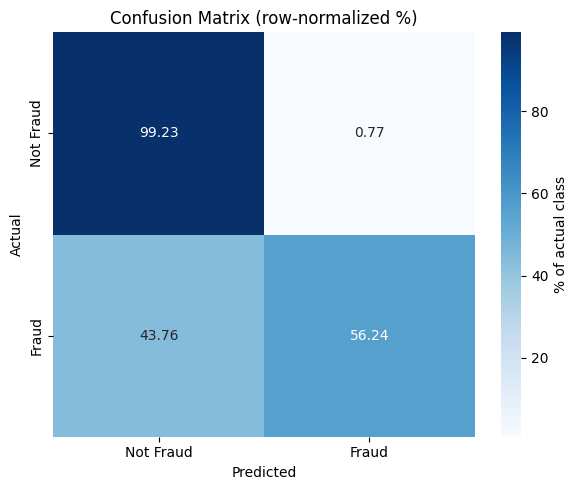

In [252]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_pct, annot=True, fmt='.2f', cmap='Blues',
           xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'],
           cbar_kws={'label': '% of actual class'}, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix (row-normalized %)')
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150)
plt.show()

In [253]:
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

print("\nFull classification report:")
print(classification_report(y_true, y_pred, target_names=['Not Fraud', 'Fraud']))

Precision: 0.7248
Recall:    0.5624
F1 Score:  0.6333

Full classification report:
              precision    recall  f1-score   support

   Not Fraud       0.98      0.99      0.99    569877
       Fraud       0.72      0.56      0.63     20663

    accuracy                           0.98    590540
   macro avg       0.85      0.78      0.81    590540
weighted avg       0.98      0.98      0.98    590540



In [255]:
pr_auc = average_precision_score(y_true, y_prob)
print(f"PR-AUC (Average Precision): {pr_auc:.4f}")

PR-AUC (Average Precision): 0.6617


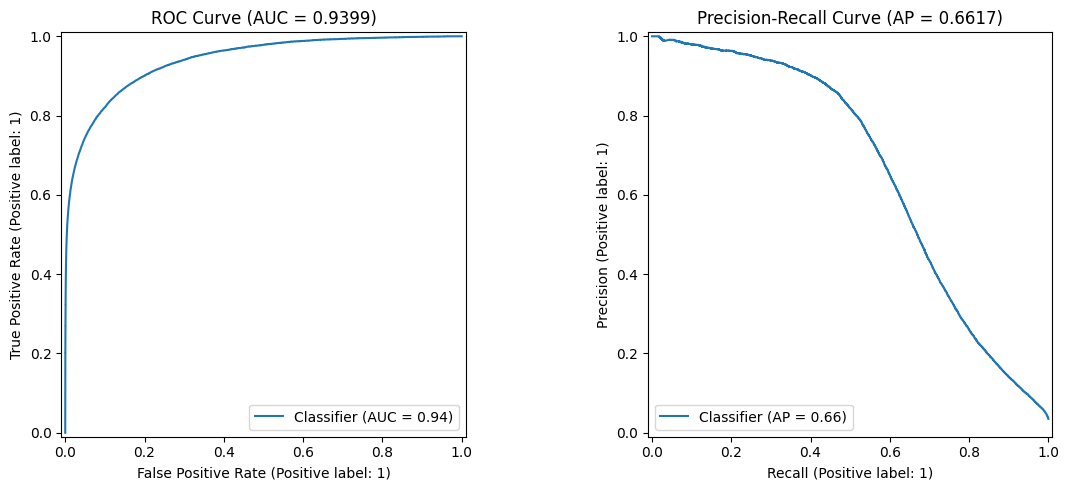

In [256]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
RocCurveDisplay.from_predictions(y_true, y_prob, ax=axes[0])
axes[0].set_title(f'ROC Curve (AUC = {roc_auc_score(y_true, y_prob):.4f})')

PrecisionRecallDisplay.from_predictions(y_true, y_prob, ax=axes[1])
axes[1].set_title(f'Precision-Recall Curve (AP = {pr_auc:.4f})')

plt.tight_layout()
plt.savefig('/kaggle/working/evaluation_curves.png', dpi=150)
plt.show()